<a href="https://colab.research.google.com/github/mnitin3/Cypher_2026_SLM/blob/main/MediLearn_Hybrid_Agentic_RAG_Workshop_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Not Every Agent Needs a Frontier Model
### Hybrid SLM/LLM Pipelines + Agentic RAG — Workshop Notebook (v2)

**Cypher 2026 — Nitin Agarwal**

This notebook is a clean, self-contained build for the workshop. It does **not** depend on any
earlier fine-tuned checkpoint — every model is pulled fresh from Hugging Face.

| Role | Model | Why |
|---|---|---|
| **SLM** (small, cheap, fast) | `Qwen2.5-0.5B-Instruct` | ~1GB, runs happily on CPU or a sliver of a T4. Used for drafting, classification, extraction, routing, reranking, and — the point of this workshop — **orchestration**. |
| **LLM** (frontier-ish, slow, expensive) | `Llama-3.1-8B-Instruct` (4-bit) | Reserved for open-ended synthesis, ambiguity resolution, and judgment calls. |

### What changed in v2 (and why)
The first run showed that the always-on stage-split hybrid matched LLM-only quality but cost *more* and ran *slower*, and that
the agentic router's escalation decisions didn't track where the SLM was actually wrong. v2 keeps that finding visible and tests fixes:

* **A cascade pipeline** (Section 3.5): the SLM answers first; a cheap, non-generative **confidence gate** decides whether to escalate to the LLM.
* **A calibrated gate** (Section 5): the escalation threshold is tuned on a *dev split* and reported on a held-out *test split*, with a quality-vs-cost **Pareto curve** against random and oracle routing.
* **Leaner hybrid v1**: two stages (intent, extraction) were computed but never used downstream — removed. Retrieval now uses the original *and* rewritten query (a 0.5B rewriter can drift).
* **A harder, bigger eval**: 48 questions (under the 50 cap), a 52-document KB with near-neighbour distractors, six multi-hop L3 questions, and a tighter judge rubric.
* **Honest statistics**: bootstrap confidence intervals, paired win/tie/loss counts, a pre-defined question audit, cost sensitivity, and a human-review export.

### What you'll build, in order
1. **Section 1** — Load both models + a shared retrieval corpus (ChromaDB) + the 48-question eval set.
2. **Section 2** — Two baselines, the two ends of the spectrum: **SLM-only** RAG and **Passive RAG / LLM-only**.
3. **Section 3** — **Hybrid v1** (stage-split) and **3.5 Hybrid Cascade** (SLM first, gate decides escalation).
4. **Section 4** — **Agentic RAG**: SLM-orchestrated multi-agent routing + self-reflection, now with the calibrated gate as a safety net.
5. **Section 5** — Evaluation across **five** pipelines with an independent **LLM-judge rubric** as the primary metric, plus latency, call mix, cost (with sensitivity), and uncertainty.

> **Runtime:** Colab, free T4 GPU. `Runtime → Change runtime type → T4 GPU`.
> **Plan for time:** a cold full run is roughly 30–45 min on a T4 (an estimate from the v1 latencies, not measured). Run it once *before* the workshop —
> every pipeline's results are cached to Drive, so live you just reload them (`FORCE_RERUN = False`).
> **Gated model note:** `Llama-3.1-8B-Instruct` requires accepting Meta's license on its Hugging Face model page and a HF token with read access. Add it to Colab secrets as `HF_TOKEN` (key icon in the left sidebar) *before* running Section 1.

---
## Section 0 — Install & Imports

In [5]:
# ============================================================
# INSTALL (Colab T4 — run once)
# ============================================================
!pip install -q -U transformers accelerate bitsandbytes sentence-transformers chromadb pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140

In [6]:
import os, json, re, time, random, warnings
from typing import List, Dict, Tuple, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

random.seed(42)
np.random.seed(42)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


GPU available: True
Device: Tesla T4


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# HF auth (needed for the gated Llama-3.1 checkpoint)
from huggingface_hub import login

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN)
    print("✓ Logged in to Hugging Face")
else:
    print("⚠️  No HF_TOKEN found. Add one in Colab secrets (key icon, left sidebar) "
          "and accept the Llama-3.1-8B-Instruct license on its model page, or this "
          "notebook will fail to load the LLM in the next section.")


✓ Logged in to Hugging Face


In [9]:
# ============================================================
# WORKSHOP SETTINGS — the only cell you should need to edit
# ============================================================
OUT_DIR     = "/content/drive/MyDrive/Cypher - Hybrid RAG"
RESULTS_DIR = f"{OUT_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FORCE_RERUN         = False  # False = reuse cached per-pipeline results if they exist (pre-run before the workshop!)
TARGET_QUALITY_FRAC = 0.98   # the cascade gate is calibrated to keep >= 98% of Passive RAG's dev-set quality
NEED_MARGIN         = 0.5    # "the LLM was needed" = its answer scored >= 0.5 judge-points above the SLM's
BOOTSTRAP_N         = 2000   # resamples for confidence intervals
MANUAL_EXCLUDE      = {}     # {"Q07": "reference answer contradicts the KB"} — a written reason is mandatory
MAX_AUTO_EXCLUDE_FRAC = 0.10  # the audit may auto-exclude at most 10% of questions; beyond that it refuses (see 5.4)

print("✓ Settings loaded — results cache:", RESULTS_DIR)

✓ Settings loaded — results cache: /content/drive/MyDrive/Cypher - Hybrid RAG/results


---
## Section 1 — Load the Two Models

Two generic wrappers, `slm_complete()` and `llm_complete()`, are the *only* way any pipeline
stage below talks to a model. Every call is logged (model tier, stage name, latency, rough token
counts) so Section 5 can reconstruct the full SLM/LLM call-mix and cost picture with zero extra
instrumentation later.


In [10]:
# ============================================================
# SLM: Qwen2.5-0.5B-Instruct
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

SLM_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
# SLM_MODEL_ID ="mohres/SmolLM-135M-Instruct-medical_meadow_medical_flashcards-10epochs"
# LLM_MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"
LLM_MODEL_ID = "Qwen/Qwen3-8B"
print(f"Loading SLM: {SLM_MODEL_ID} ...")
slm_tokenizer = AutoTokenizer.from_pretrained(SLM_MODEL_ID)
slm_model = AutoModelForCausalLM.from_pretrained(
    SLM_MODEL_ID, torch_dtype=torch.float16, device_map="auto"
)
print("✓ SLM loaded —", sum(p.numel() for p in slm_model.parameters()) / 1e6, "M params")

Loading SLM: Qwen/Qwen2.5-0.5B-Instruct ...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ SLM loaded — 494.032768 M params


In [11]:
# ============================================================
# LLM: Llama-3.1-8B-Instruct, 4-bit (fits comfortably on a T4)
# ============================================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"Loading LLM: {LLM_MODEL_ID} (4-bit) ...")
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID)
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
print("✓ LLM loaded (4-bit)")


Loading LLM: Qwen/Qwen3-8B (4-bit) ...


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ LLM loaded (4-bit)


In [12]:
# ============================================================
# GENERIC CALL WRAPPERS + CALL LOG
# Everything downstream (hybrid pipeline, agentic layer, eval) calls ONLY
# these two functions. That's what makes the call-mix / cost analysis in
# Section 5 accurate without any special-casing.
# ============================================================
_CALL_LOG = []  # list of dicts: {stage, tier, latency_s, prompt_tokens, completion_tokens}

def _log_call(stage: str, tier: str, latency_s: float, prompt: str, completion: str):
    _CALL_LOG.append({
        "stage": stage,
        "tier": tier,
        "latency_s": latency_s,
        "prompt_tokens": len(prompt.split()),
        "completion_tokens": len(completion.split()),
    })

def _chat_generate(model, tokenizer, system: str, user: str, max_new_tokens: int, temperature: float) -> str:
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=max(temperature, 0.01),
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return text.strip()

def slm_complete(user_prompt: str, system: str = "You are a concise, accurate medical assistant.",
                  max_tokens: int = 150, temperature: float = 0.3, stage: str = "unlabeled") -> str:
    '''[SLM] Qwen2.5-0.5B-Instruct — cheap, fast, used for mechanical/closed-set stages.'''
    t0 = time.time()
    result = _chat_generate(slm_model, slm_tokenizer, system, user_prompt, max_tokens, temperature)
    _log_call(stage, "SLM", time.time() - t0, user_prompt, result)
    return result

def llm_complete(user_prompt: str, system: str = "You are a careful, thorough medical educator.",
                  max_tokens: int = 300, temperature: float = 0.4, stage: str = "unlabeled") -> str:
    '''[LLM] Llama-3.1-8B-Instruct (4-bit) — reserved for open-ended judgment calls.'''
    t0 = time.time()
    result = _chat_generate(llm_model, llm_tokenizer, system, user_prompt, max_tokens, temperature)
    _log_call(stage, "LLM", time.time() - t0, user_prompt, result)
    return result

print("✓ slm_complete() and llm_complete() ready, all calls logged to _CALL_LOG")


✓ slm_complete() and llm_complete() ready, all calls logged to _CALL_LOG


### 1.1 Embedding model (for retrieval + semantic scoring) and knowledge base

A small `sentence-transformers` model powers both the vector store and the semantic-similarity
metric in Section 5, so retrieval and scoring stay consistent with each other.


In [13]:
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb

embedder = SentenceTransformer("all-MiniLM-L6-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")  # small, purpose-built — counts as an [SLM]-tier stage
print("✓ Embedding model + cross-encoder reranker loaded")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✓ Embedding model + cross-encoder reranker loaded


In [14]:
# ============================================================
# COMPACT MEDICAL KNOWLEDGE BASE
# Still small — this workshop is about pipeline architecture — but v2 adds near-neighbour distractor docs
# (52 docs total) so retrieval is no longer trivial.
# Three doc "types" mirror a real clinical RAG corpus: guidelines, cases, mechanism notes.
# ============================================================
KNOWLEDGE_BASE = [
    # -- Cardiology --
    {"id": "kb001", "category": "Cardiology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Acute STEMI. First-line treatment: primary PCI within 90 minutes "
             "of first medical contact. If PCI unavailable within 120 minutes, administer fibrinolytics. "
             "Dual antiplatelet therapy (aspirin + P2Y12 inhibitor) is standard. Contraindication: "
             "active bleeding or recent major surgery for fibrinolytics."},
    {"id": "kb002", "category": "Cardiology", "type": "case",
     "text": "CASE: 58-year-old male, crushing substernal chest pain radiating to left arm, diaphoresis. "
             "ECG shows ST elevation in leads II, III, aVF. Diagnosis: inferior STEMI. "
             "Treatment: emergent cardiac catheterization."},
    {"id": "kb003", "category": "Cardiology", "type": "knowledge",
     "text": "Beta-blockers reduce myocardial oxygen demand by lowering heart rate and contractility. "
             "In heart failure with reduced ejection fraction, they reduce mortality by blunting "
             "chronic sympathetic overactivation of the heart."},
    # -- Neurology --
    {"id": "kb004", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Acute ischemic stroke. IV alteplase (tPA) within 4.5 hours of symptom "
             "onset if no contraindications. Mechanical thrombectomy for large-vessel occlusion within "
             "24 hours in eligible patients. Contraindication: recent intracranial hemorrhage, "
             "active bleeding, BP > 185/110 uncontrolled."},
    {"id": "kb005", "category": "Neurology", "type": "case",
     "text": "CASE: 71-year-old female, sudden left-sided weakness and facial droop, symptom onset 90 "
             "minutes ago. NIHSS 14. Diagnosis: acute ischemic stroke, right MCA territory. "
             "Treatment: IV alteplase administered, CTA shows large-vessel occlusion, "
             "taken for thrombectomy."},
    {"id": "kb006", "category": "Neurology", "type": "knowledge",
     "text": "In ischemic stroke, the penumbra is tissue that is hypoperfused but not yet infarcted — "
             "it remains salvageable with timely reperfusion, which is why 'time is brain' drives "
             "the urgency of thrombolysis and thrombectomy."},
    # -- Respiratory --
    {"id": "kb007", "category": "Respiratory", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Community-acquired pneumonia, outpatient. First-line treatment: "
             "amoxicillin or doxycycline for healthy adults without comorbidities. For patients with "
             "comorbidities, a respiratory fluoroquinolone or beta-lactam plus macrolide. "
             "Dosage: amoxicillin 1g three times daily for 5-7 days."},
    {"id": "kb008", "category": "Respiratory", "type": "case",
     "text": "CASE: 45-year-old, productive cough, fever, pleuritic chest pain for 3 days. "
             "Chest X-ray shows right lower lobe consolidation. Diagnosis: community-acquired "
             "pneumonia. Treatment: outpatient amoxicillin, follow-up in 48-72 hours."},
    {"id": "kb009", "category": "Respiratory", "type": "knowledge",
     "text": "Asthma pathophysiology involves airway hyperresponsiveness, chronic eosinophilic "
             "inflammation, and reversible bronchoconstriction. Beta-2 agonists relax airway "
             "smooth muscle by increasing cyclic AMP."},
    # -- Endocrine --
    {"id": "kb010", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Type 2 diabetes, first-line pharmacotherapy is metformin plus "
             "lifestyle modification, target HbA1c generally < 7%. Contraindication: eGFR < 30 "
             "mL/min/1.73m2 (risk of lactic acidosis). Dosage: start 500mg once or twice daily, "
             "titrate up."},
    {"id": "kb011", "category": "Endocrine", "type": "case",
     "text": "CASE: 52-year-old, polyuria, polydipsia, fasting glucose 210 mg/dL, HbA1c 8.9%. "
             "Diagnosis: type 2 diabetes mellitus. Treatment: metformin initiated, dietitian referral."},
    {"id": "kb012", "category": "Endocrine", "type": "knowledge",
     "text": "Metformin's primary mechanism is reducing hepatic gluconeogenesis and improving "
             "peripheral insulin sensitivity, rather than stimulating insulin secretion — "
             "this is why it carries a low risk of hypoglycemia on its own."},
    # -- Critical Care --
    {"id": "kb013", "category": "Critical Care", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Sepsis / septic shock. Within the first hour: obtain blood cultures, "
             "measure lactate, administer broad-spectrum antibiotics, begin 30 mL/kg crystalloid for "
             "hypotension or lactate >= 4 mmol/L. Start vasopressors (norepinephrine first-line) if "
             "MAP < 65 mmHg after fluids."},
    {"id": "kb014", "category": "Critical Care", "type": "case",
     "text": "CASE: 67-year-old, fever, hypotension (BP 82/50), lactate 5.2, source likely urinary. "
             "Diagnosis: septic shock. Treatment: broad-spectrum antibiotics, 30mL/kg fluids, "
             "norepinephrine started for persistent hypotension."},
    {"id": "kb015", "category": "Critical Care", "type": "knowledge",
     "text": "Septic shock physiology combines vasodilation, capillary leak, and myocardial depression, "
             "producing a distributive shock state where fluids alone often can't restore perfusion, "
             "which is why vasopressors are escalated early rather than with unlimited fluid boluses."},
    # -- Pharmacology --
    {"id": "kb016", "category": "Pharmacology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Warfarin dosing and monitoring. Target INR 2.0-3.0 for most "
             "indications (2.5-3.5 for mechanical mitral valves). Contraindication: active bleeding, "
             "pregnancy. Interacts with many drugs (e.g., NSAIDs, some antibiotics) and vitamin K intake."},
    {"id": "kb017", "category": "Pharmacology", "type": "case",
     "text": "CASE: 63-year-old on warfarin for atrial fibrillation presents with INR 6.8, no bleeding. "
             "Management: hold warfarin, consider low-dose oral vitamin K, recheck INR in 24 hours."},
    {"id": "kb018", "category": "Pharmacology", "type": "knowledge",
     "text": "Warfarin inhibits vitamin K epoxide reductase, blocking synthesis of clotting factors "
             "II, VII, IX, and X. Its narrow therapeutic index and many drug/food interactions "
             "are why it requires regular INR monitoring, unlike the direct oral anticoagulants."},

    # ==========================================================
    # v2 ADDITIONS — 34 more documents. Each new question has its support doc(s), and every
    # category now has near-neighbour "distractor" docs (NSTEMI vs STEMI, ICH vs ischemic stroke,
    # PE vs pneumothorax, hypoglycemia vs DKA, ...) so retrieval is no longer trivial.
    # ==========================================================
    # -- Cardiology --
    {"id": "kb019", "category": "Cardiology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: NSTEMI / non-ST-elevation acute coronary syndrome. Initial therapy: aspirin plus a P2Y12 "
             "inhibitor, heparin anticoagulation, and anti-ischemic therapy. The invasive strategy is risk-stratified: immediate "
             "angiography (within 2 hours) for refractory chest pain, hemodynamic instability, or life-threatening arrhythmia; "
             "early angiography (within 24 hours) for high-risk patients such as GRACE score > 140; otherwise within 72 hours. "
             "Fibrinolytics are not indicated in NSTEMI."},
    {"id": "kb020", "category": "Cardiology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Atrial fibrillation. Hemodynamically unstable AF (hypotension, altered mental status, ongoing "
             "ischemia, acute heart failure) requires immediate synchronized electrical cardioversion. In stable patients, control "
             "the ventricular rate with a beta-blocker or a non-dihydropyridine calcium channel blocker such as diltiazem, avoiding "
             "diltiazem when ejection fraction is reduced. Anticoagulation is guided by CHA2DS2-VASc: recommended for a score of 2 or "
             "more in men or 3 or more in women, with direct oral anticoagulants preferred over warfarin in most patients."},
    {"id": "kb021", "category": "Cardiology", "type": "knowledge",
     "text": "Right ventricular infarction complicates some inferior STEMIs. The right ventricle is preload-dependent, so nitrates, "
             "diuretics, and other venodilators cause a sharp fall in preload and can precipitate severe hypotension. Management "
             "is IV fluid loading to maintain right ventricle preload, and avoiding nitroglycerin."},
    {"id": "kb022", "category": "Cardiology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Chronic stable angina. Long-term single antiplatelet therapy with low-dose aspirin (clopidogrel if "
             "aspirin-intolerant), a beta-blocker or calcium channel blocker for symptom control, sublingual nitroglycerin for acute "
             "episodes, and a high-intensity statin. Dual antiplatelet therapy is not used long-term in stable disease."},
    {"id": "kb023", "category": "Cardiology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Heart failure with reduced ejection fraction (HFrEF). Four mortality-reducing drug classes: an "
             "evidence-based beta-blocker (carvedilol, metoprolol succinate, bisoprolol), ACE inhibitor/ARB/ARNI, mineralocorticoid "
             "receptor antagonist, and SGLT2 inhibitor. Loop diuretics relieve congestion but do not reduce mortality."},
    # -- Neurology --
    {"id": "kb024", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Acute stroke imaging. Obtain an urgent non-contrast head CT first to exclude intracranial hemorrhage "
             "before any thrombolysis; hemorrhage on CT is an absolute contraindication to alteplase. CT angiography is added to "
             "identify large-vessel occlusion for thrombectomy. MRI is not required before treatment."},
    {"id": "kb025", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Subarachnoid hemorrhage. Thunderclap headache ('worst headache of life') requires urgent non-contrast "
             "head CT, which is close to 100% sensitive within 6 hours of onset but loses sensitivity afterward. If CT is negative "
             "and more than 6 hours have passed, perform lumbar puncture looking for xanthochromia (or CT angiography). Confirmed "
             "aneurysmal subarachnoid hemorrhage is managed with early aneurysm securing and nimodipine."},
    {"id": "kb026", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Status epilepticus. A seizure lasting more than 5 minutes, or recurrent seizures without recovery "
             "between them, is status epilepticus. First-line treatment is a benzodiazepine: IV lorazepam 4 mg (may repeat once), or "
             "IM midazolam if there is no IV access. If seizures persist, give a second-line antiseizure drug such as levetiracetam, "
             "fosphenytoin, or valproate."},
    {"id": "kb027", "category": "Neurology", "type": "knowledge",
     "text": "Prolonged seizures become self-sustaining and drug-resistant: with continued activity, synaptic GABA-A receptors are "
             "internalized (reducing benzodiazepine efficacy) while excitatory NMDA receptors are upregulated. Prolonged seizures also "
             "cause neuronal injury, which is why treatment starts at 5 minutes rather than waiting."},
    {"id": "kb028", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Thrombolysis eligibility and anticoagulants. Use of a direct oral anticoagulant (apixaban, rivaroxaban, "
             "dabigatran) within the previous 48 hours is a contraindication to IV alteplase unless drug-specific tests are normal. "
             "Warfarin with INR > 1.7 is also a contraindication. These patients can still be evaluated for mechanical thrombectomy "
             "if CT angiography shows a large-vessel occlusion."},
    {"id": "kb029", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Intracerebral hemorrhage. Thrombolytics are contraindicated. Manage with rapid blood pressure lowering "
             "(systolic target about 140 mmHg), reversal of any anticoagulant, and neurosurgical evaluation for cerebellar "
             "hemorrhage or hydrocephalus."},
    {"id": "kb030", "category": "Neurology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Transient ischemic attack. Symptoms resolve within 24 hours, usually within one hour. Urgent "
             "evaluation with brain imaging and vascular studies, then dual antiplatelet therapy (aspirin plus clopidogrel) for "
             "21 days after a high-risk TIA, plus statin therapy."},
    # -- Respiratory --
    {"id": "kb031", "category": "Respiratory", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Acute asthma exacerbation. The first-line reliever is a short-acting beta-2 agonist (albuterol/salbutamol) "
             "given repeatedly by nebulizer or metered-dose inhaler with spacer. Add ipratropium for severe exacerbations and give early "
             "systemic corticosteroids (prednisone 40-60 mg). IV magnesium sulfate is reserved for life-threatening attacks."},
    {"id": "kb032", "category": "Respiratory", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Primary spontaneous pneumothorax, typically tall thin young men with sudden pleuritic chest pain and "
             "dyspnea. If the patient is stable and the rim of air is small (< 2 cm), observe with supplemental oxygen. If the rim is "
             "2 cm or larger or the patient is symptomatic, perform needle aspiration or small-bore catheter drainage; use a chest "
             "tube if this fails. Tension pneumothorax with hemodynamic compromise requires immediate needle decompression."},
    {"id": "kb033", "category": "Respiratory", "type": "guideline",
     "text": "CLINICAL GUIDELINE: COPD exacerbation (increased dyspnea, cough, or sputum purulence). Treat with short-acting "
             "bronchodilators (albuterol plus ipratropium), systemic corticosteroids (prednisone 40 mg daily for 5 days), and "
             "antibiotics when sputum purulence is present together with increased dyspnea or sputum volume. Use noninvasive "
             "ventilation for respiratory acidosis (pH < 7.35 with elevated PaCO2)."},
    {"id": "kb034", "category": "Respiratory", "type": "knowledge",
     "text": "Oxygen therapy in COPD with chronic hypercapnia should be titrated to a saturation of 88-92%. Excess oxygen worsens "
             "hypercapnia mainly by releasing hypoxic pulmonary vasoconstriction (worsening V/Q mismatch) and through the Haldane "
             "effect, in which oxygenated hemoglobin binds less CO2; loss of hypoxic respiratory drive plays a smaller role."},
    {"id": "kb035", "category": "Respiratory", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Pulmonary embolism. Pleuritic chest pain, dyspnea, tachycardia. Estimate pretest probability with the "
             "Wells score; D-dimer if low probability, CT pulmonary angiography if high. Treat with anticoagulation (DOAC preferred); "
             "systemic thrombolysis for hemodynamically unstable high-risk pulmonary embolism."},
    # -- Endocrine --
    {"id": "kb036", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Diagnosis of diabetes mellitus. Any one of: HbA1c >= 6.5%, fasting plasma glucose >= 126 mg/dL, "
             "2-hour glucose >= 200 mg/dL on a 75 g oral glucose tolerance test, or random glucose >= 200 mg/dL with classic "
             "hyperglycemic symptoms. Prediabetes is an HbA1c of 5.7-6.4%."},
    {"id": "kb037", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Diabetic ketoacidosis (DKA): glucose typically above 200-250 mg/dL, arterial pH < 7.3, bicarbonate "
             "< 18 mmol/L, and ketonemia or ketonuria. Initial management: IV isotonic fluids first, then a continuous IV insulin "
             "infusion only once serum potassium is confirmed to be at least 3.3 mmol/L (3.5 in newer consensus); add potassium "
             "replacement when potassium is below 5.3 mmol/L. Monitor glucose and electrolytes frequently and add dextrose when "
             "glucose falls to about 200-250 mg/dL."},
    {"id": "kb038", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Type 2 diabetes with established atherosclerotic cardiovascular disease, heart failure, or chronic "
             "kidney disease. Add a GLP-1 receptor agonist or an SGLT2 inhibitor with proven cardiovascular benefit, independent of "
             "baseline HbA1c, alongside metformin. SGLT2 inhibitors also reduce heart failure hospitalization and slow CKD "
             "progression; genital mycotic infections and euglycemic ketoacidosis are notable adverse effects."},
    {"id": "kb039", "category": "Endocrine", "type": "knowledge",
     "text": "In DKA, total body potassium is depleted by osmotic diuresis even when the serum potassium is normal or high, because "
             "acidosis and insulin deficiency shift potassium out of cells. Insulin drives potassium back into cells, so starting "
             "insulin without checking and replacing potassium can cause life-threatening hypokalemia and arrhythmia."},
    {"id": "kb040", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Diabetes with reduced kidney function. Metformin is contraindicated when eGFR < 30 mL/min/1.73m2 "
             "because of the risk of lactic acidosis; reduce the dose when eGFR is 30-45. In advanced CKD, GLP-1 receptor agonists "
             "or insulin (with dose reduction) are used for glycemic control. SGLT2 inhibitors are continued for kidney and cardiac "
             "protection but lower glucose little when eGFR is low."},
    {"id": "kb041", "category": "Endocrine", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Hypoglycemia (glucose < 70 mg/dL). Conscious patients: 15-20 g of fast-acting oral glucose, recheck "
             "in 15 minutes. If unable to take oral: IV dextrose or IM/intranasal glucagon. Insulin and sulfonylureas are the most "
             "common causes."},
    # -- Critical Care --
    {"id": "kb042", "category": "Critical Care", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Fluid choice in sepsis. Balanced crystalloids (lactated Ringer's, Plasma-Lyte) are suggested over "
             "normal saline for initial resuscitation because large volumes of saline cause hyperchloremic metabolic acidosis. "
             "Albumin may be added when large volumes of crystalloid are needed. Hydroxyethyl starch should be avoided."},
    {"id": "kb043", "category": "Critical Care", "type": "guideline",
     "text": "CLINICAL GUIDELINE: ARDS (PaO2/FiO2 <= 300 with bilateral infiltrates not fully explained by cardiac failure). Use "
             "lung-protective ventilation: tidal volume 6 mL/kg predicted body weight and plateau pressure < 30 cmH2O. For "
             "moderate-to-severe ARDS (PaO2/FiO2 < 150) use prone positioning for at least 12-16 hours per day, and apply a "
             "conservative fluid strategy once shock has resolved."},
    {"id": "kb044", "category": "Critical Care", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Severe hyperkalemia (K >= 6.5 mmol/L, or ECG changes such as peaked T waves and widened QRS). "
             "Immediately give IV calcium gluconate to stabilize the cardiac membrane; it protects the myocardium but does not "
             "lower potassium. Then shift potassium into cells with IV insulin plus dextrose and nebulized albuterol, and remove it "
             "with loop diuretics, potassium binders, or dialysis."},
    {"id": "kb045", "category": "Critical Care", "type": "knowledge",
     "text": "In ARDS, the aerated lung is a small fraction of normal (the 'baby lung'). Large tidal volumes overdistend these "
             "remaining healthy alveoli, causing volutrauma and ventilator-induced lung injury with inflammation, which is why "
             "low tidal volume ventilation lowers mortality."},
    {"id": "kb046", "category": "Critical Care", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Cardiogenic shock. Hypotension with cold, clammy extremities, high filling pressures, and low cardiac "
             "output. Treat the cause (revascularization for MI), use norepinephrine for hypotension and inotropes such as "
             "dobutamine, and avoid large fluid boluses when pulmonary congestion is present."},
    # -- Pharmacology --
    {"id": "kb047", "category": "Pharmacology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Reversal of direct oral anticoagulants in life-threatening bleeding. Dabigatran: idarucizumab (a "
             "specific antibody fragment). Apixaban and rivaroxaban: andexanet alfa, or 4-factor prothrombin complex concentrate if "
             "andexanet is unavailable."},
    {"id": "kb048", "category": "Pharmacology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Warfarin-associated major bleeding. Stop warfarin and give IV vitamin K 5-10 mg together with "
             "4-factor prothrombin complex concentrate (preferred over fresh frozen plasma) for immediate reversal. Vitamin K alone "
             "takes 6-24 hours to act."},
    {"id": "kb049", "category": "Pharmacology", "type": "knowledge",
     "text": "ACE inhibitors (e.g., lisinopril) block the degradation of bradykinin, which accumulates and causes a dry persistent "
             "cough in roughly 10% of patients. Switching to an angiotensin receptor blocker (e.g., losartan), which does not affect "
             "bradykinin, usually resolves it. Angioedema is a rarer, more serious bradykinin-mediated adverse effect."},
    {"id": "kb050", "category": "Pharmacology", "type": "knowledge",
     "text": "Rifampin is a potent inducer of hepatic cytochrome P450 enzymes (CYP2C9, CYP3A4, CYP1A2), increasing the clearance of "
             "many drugs. Patients on warfarin who start rifampin have a falling INR and need substantially higher warfarin doses "
             "with close INR monitoring; the effect persists for weeks after rifampin is stopped."},
    {"id": "kb051", "category": "Pharmacology", "type": "knowledge",
     "text": "Antibiotics can raise the INR in patients on warfarin: some (trimethoprim-sulfamethoxazole, metronidazole, fluconazole) "
             "inhibit CYP2C9, which metabolizes the potent S-enantiomer of warfarin, and broad-spectrum agents reduce vitamin "
             "K-producing gut bacteria. The INR should be checked within 3-5 days of starting an interacting antibiotic."},
    {"id": "kb052", "category": "Pharmacology", "type": "guideline",
     "text": "CLINICAL GUIDELINE: Heparin. Unfractionated heparin is monitored by aPTT or anti-Xa level and reversed with protamine "
             "sulfate. In heparin-induced thrombocytopenia, stop all heparin and start a non-heparin anticoagulant such as argatroban."},
]

client = chromadb.Client()
try:
    client.delete_collection("medilearn_kb")
except Exception:
    pass
collection = client.create_collection("medilearn_kb")

collection.add(
    ids=[d["id"] for d in KNOWLEDGE_BASE],
    documents=[d["text"] for d in KNOWLEDGE_BASE],
    embeddings=embedder.encode([d["text"] for d in KNOWLEDGE_BASE]).tolist(),
    metadatas=[{"category": d["category"], "type": d["type"]} for d in KNOWLEDGE_BASE],
)
print(f"✓ Knowledge base loaded — {collection.count()} documents across "
      f"{len(set(d['category'] for d in KNOWLEDGE_BASE))} categories")

def retrieve(query: str, k: int = 6) -> List[str]:
    '''Unchanged bi-encoder retrieval, shared by every pipeline below.'''
    q_emb = embedder.encode([query]).tolist()
    res = collection.query(query_embeddings=q_emb, n_results=k)
    return res["documents"][0]


✓ Knowledge base loaded — 52 documents across 6 categories


### 1.2 Evaluation set (48 questions — kept under the 50 cap so the live run stays short)

Same schema as before (`id`, `category`, `difficulty`, `question`, `key_terms`, `reference_answer`). v2 changes:

* **48 questions**, 8 per category (12 L1 / 18 L2 / 18 L3). The original 18 are Q01–Q18, unchanged.
* **Six multi-hop L3 questions** (Q23, Q28, Q33, Q38, Q43, Q48) need facts from *two* documents.
* **A 52-document KB with near-neighbour distractors** (NSTEMI vs STEMI, hemorrhagic vs ischemic stroke, PE vs pneumothorax, hypoglycemia vs DKA…). In v1 each answer sat in one of only 18 documents, so retrieval was close to trivial and Passive RAG hit the 5.0 ceiling on 17 of 18 questions.

> **Why no question was deleted for "making results look bad":** every v1 reference answer is supported by the KB, so the low scores were *pipeline* failures,
> not question defects. Deleting the questions your pipeline fails is cherry-picking. Instead, Section 5 applies a **pre-defined, pipeline-agnostic audit**
> and prints exactly which questions (if any) it excludes and why.

In [15]:
EVAL_SET = [
    {"id": "Q01", "category": "Cardiology", "difficulty": "L1", "question": "What is the first-line treatment for acute STEMI?",
     "key_terms": ["pci", "fibrinolytic", "90 minutes"], "reference_answer": "Primary PCI within 90 minutes of first medical contact; fibrinolytics if PCI unavailable within 120 minutes."},
    {"id": "Q02", "category": "Cardiology", "difficulty": "L2", "question": "A 58-year-old man has crushing chest pain and ST elevation in leads II, III, aVF. What is the diagnosis and next step?",
     "key_terms": ["inferior stemi", "catheterization", "pci"], "reference_answer": "Inferior STEMI; emergent cardiac catheterization / primary PCI."},
    {"id": "Q03", "category": "Cardiology", "difficulty": "L3", "question": "Why do beta-blockers reduce mortality in heart failure with reduced ejection fraction?",
     "key_terms": ["sympathetic", "oxygen demand", "contractility"], "reference_answer": "They blunt chronic sympathetic overactivation and reduce myocardial oxygen demand by lowering heart rate and contractility."},
    {"id": "Q04", "category": "Neurology", "difficulty": "L1", "question": "What is the time window for IV alteplase in acute ischemic stroke?",
     "key_terms": ["4.5 hours", "alteplase", "tpa"], "reference_answer": "Within 4.5 hours of symptom onset, absent contraindications."},
    {"id": "Q05", "category": "Neurology", "difficulty": "L2", "question": "A 71-year-old has sudden left-sided weakness 90 minutes after onset, NIHSS 14. What is the diagnosis and treatment?",
     "key_terms": ["ischemic stroke", "alteplase", "thrombectomy"], "reference_answer": "Acute ischemic stroke; IV alteplase and, if large-vessel occlusion, mechanical thrombectomy."},
    {"id": "Q06", "category": "Neurology", "difficulty": "L3", "question": "Why is 'time is brain' the guiding principle behind stroke thrombolysis?",
     "key_terms": ["penumbra", "hypoperfused", "reperfusion"], "reference_answer": "The penumbra is hypoperfused but still salvageable tissue; timely reperfusion prevents it from infarcting."},
    {"id": "Q07", "category": "Respiratory", "difficulty": "L1", "question": "What is the first-line outpatient antibiotic for community-acquired pneumonia in a healthy adult?",
     "key_terms": ["amoxicillin", "doxycycline"], "reference_answer": "Amoxicillin or doxycycline."},
    {"id": "Q08", "category": "Respiratory", "difficulty": "L2", "question": "A 45-year-old has productive cough, fever, and right lower lobe consolidation on X-ray. What is the diagnosis and management?",
     "key_terms": ["community-acquired pneumonia", "amoxicillin"], "reference_answer": "Community-acquired pneumonia; outpatient amoxicillin with follow-up in 48-72 hours."},
    {"id": "Q09", "category": "Respiratory", "difficulty": "L3", "question": "Explain the mechanism by which beta-2 agonists relieve bronchoconstriction in asthma.",
     "key_terms": ["cyclic amp", "smooth muscle", "beta-2"], "reference_answer": "They relax airway smooth muscle by increasing cyclic AMP, reversing bronchoconstriction."},
    {"id": "Q10", "category": "Endocrine", "difficulty": "L1", "question": "What is the first-line pharmacotherapy for type 2 diabetes?",
     "key_terms": ["metformin"], "reference_answer": "Metformin, alongside lifestyle modification."},
    {"id": "Q11", "category": "Endocrine", "difficulty": "L2", "question": "A 52-year-old has polyuria, polydipsia, fasting glucose 210, HbA1c 8.9%. What is the diagnosis and initial treatment?",
     "key_terms": ["type 2 diabetes", "metformin"], "reference_answer": "Type 2 diabetes mellitus; start metformin plus dietitian referral."},
    {"id": "Q12", "category": "Endocrine", "difficulty": "L3", "question": "Why does metformin carry a low risk of hypoglycemia compared to insulin secretagogues?",
     "key_terms": ["gluconeogenesis", "insulin sensitivity", "insulin secretion"], "reference_answer": "It reduces hepatic gluconeogenesis and improves insulin sensitivity rather than stimulating insulin secretion."},
    {"id": "Q13", "category": "Critical Care", "difficulty": "L1", "question": "What is the first-line vasopressor in septic shock?",
     "key_terms": ["norepinephrine"], "reference_answer": "Norepinephrine."},
    {"id": "Q14", "category": "Critical Care", "difficulty": "L2", "question": "A 67-year-old has fever, BP 82/50, lactate 5.2 with a likely urinary source. What is the diagnosis and initial management?",
     "key_terms": ["septic shock", "antibiotics", "fluids", "norepinephrine"], "reference_answer": "Septic shock; broad-spectrum antibiotics, 30 mL/kg fluids, norepinephrine if hypotension persists."},
    {"id": "Q15", "category": "Critical Care", "difficulty": "L3", "question": "Why are vasopressors escalated early in septic shock rather than giving unlimited fluids?",
     "key_terms": ["distributive shock", "capillary leak", "myocardial depression"], "reference_answer": "Septic shock is distributive with capillary leak and myocardial depression, so fluids alone often can't restore perfusion."},
    {"id": "Q16", "category": "Pharmacology", "difficulty": "L1", "question": "What is the target INR range for warfarin in most indications?",
     "key_terms": ["2.0", "3.0", "inr"], "reference_answer": "2.0 to 3.0 for most indications."},
    {"id": "Q17", "category": "Pharmacology", "difficulty": "L2", "question": "A patient on warfarin for atrial fibrillation has an INR of 6.8 with no bleeding. What is the management?",
     "key_terms": ["hold warfarin", "vitamin k", "recheck inr"], "reference_answer": "Hold warfarin, consider low-dose oral vitamin K, recheck INR in 24 hours."},
    {"id": "Q18", "category": "Pharmacology", "difficulty": "L3", "question": "Why does warfarin require regular INR monitoring while direct oral anticoagulants generally do not?",
     "key_terms": ["vitamin k epoxide reductase", "narrow therapeutic index", "interactions"], "reference_answer": "It inhibits vitamin K epoxide reductase with a narrow therapeutic index and many interactions, unlike DOACs."},

    # ---- v2 additions: Q19-Q48 (30 questions) -> 48 total, 8 per category, capped under 50 ----
    # Mix: more L2 case vignettes and L3 questions, including 6 multi-hop L3 items that need TWO documents.
    # Cardiology
    {"id": "Q19", "category": "Cardiology", "difficulty": "L1", "question": "Which antiplatelet combination is standard after an acute STEMI?",
     "key_terms": ["aspirin", "p2y12"], "reference_answer": "Dual antiplatelet therapy: aspirin plus a P2Y12 inhibitor."},
    {"id": "Q20", "category": "Cardiology", "difficulty": "L2", "question": "A 64-year-old woman with new atrial fibrillation has a heart rate of 150, BP 88/50, and confusion. What is the next step?",
     "key_terms": ["unstable", "synchronized", "cardioversion"], "reference_answer": "Hemodynamically unstable AF needs immediate synchronized electrical cardioversion."},
    {"id": "Q21", "category": "Cardiology", "difficulty": "L2", "question": "A patient with NSTEMI has refractory chest pain despite medical therapy. How quickly should angiography be done?",
     "key_terms": ["immediate", "2 hours", "refractory"], "reference_answer": "An immediate invasive strategy: angiography within 2 hours."},
    {"id": "Q22", "category": "Cardiology", "difficulty": "L3", "question": "Why is nitroglycerin avoided in an inferior STEMI with right ventricular involvement?",
     "key_terms": ["preload", "hypotension", "right ventricle"], "reference_answer": "The right ventricle is preload-dependent; nitrates cause venodilation and a fall in preload, risking severe hypotension."},
    {"id": "Q23", "category": "Cardiology", "difficulty": "L3", "question": "A 70-year-old man with HFrEF develops atrial fibrillation with a CHA2DS2-VASc score of 4. Which drug class reduces heart-failure mortality while also controlling rate, and what is needed for stroke prevention?",
     "key_terms": ["beta-blocker", "anticoagulation", "direct oral anticoagulants"], "reference_answer": "An evidence-based beta-blocker lowers mortality and controls rate; oral anticoagulation, preferably a direct oral anticoagulant, is needed for stroke prevention."},
    # Neurology
    {"id": "Q24", "category": "Neurology", "difficulty": "L1", "question": "What imaging must be done before giving IV thrombolysis for acute stroke?",
     "key_terms": ["non-contrast", "head ct", "hemorrhage"], "reference_answer": "A non-contrast head CT to exclude intracranial hemorrhage."},
    {"id": "Q25", "category": "Neurology", "difficulty": "L2", "question": "A 30-year-old has a thunderclap headache; a non-contrast head CT done 10 hours after onset is normal. What is the next step?",
     "key_terms": ["subarachnoid", "lumbar puncture", "xanthochromia"], "reference_answer": "Suspect subarachnoid hemorrhage; CT loses sensitivity after 6 hours, so perform a lumbar puncture for xanthochromia (or CT angiography)."},
    {"id": "Q26", "category": "Neurology", "difficulty": "L2", "question": "A man is still having a generalized convulsion after 7 minutes. What is the first-line drug?",
     "key_terms": ["status epilepticus", "benzodiazepine", "lorazepam"], "reference_answer": "Status epilepticus; first-line IV benzodiazepine such as lorazepam (IM midazolam if no IV access)."},
    {"id": "Q27", "category": "Neurology", "difficulty": "L3", "question": "Why is a seizure lasting longer than 5 minutes treated as an emergency instead of waiting for it to stop?",
     "key_terms": ["gaba", "nmda", "self-sustaining"], "reference_answer": "Prolonged seizures become self-sustaining and drug-resistant as GABA-A receptors are internalized and NMDA receptors increase, and they injure neurons."},
    {"id": "Q28", "category": "Neurology", "difficulty": "L3", "question": "A patient on apixaban whose last dose was 6 hours ago presents with an acute ischemic stroke and a large-vessel occlusion. Is IV alteplase appropriate, and what is the alternative?",
     "key_terms": ["contraindication", "48 hours", "thrombectomy"], "reference_answer": "No: DOAC use within 48 hours is a contraindication to IV alteplase; evaluate for mechanical thrombectomy for the large-vessel occlusion."},
    # Respiratory
    {"id": "Q29", "category": "Respiratory", "difficulty": "L1", "question": "What is the first-line reliever for an acute asthma exacerbation?",
     "key_terms": ["short-acting beta-2 agonist", "albuterol"], "reference_answer": "An inhaled short-acting beta-2 agonist such as albuterol (salbutamol)."},
    {"id": "Q30", "category": "Respiratory", "difficulty": "L2", "question": "A tall, thin 22-year-old has sudden pleuritic chest pain and dyspnea; chest X-ray shows a 3 cm rim of air at the apex and he is hemodynamically stable. What is the diagnosis and management?",
     "key_terms": ["pneumothorax", "needle aspiration"], "reference_answer": "Primary spontaneous pneumothorax; a rim of 2 cm or more needs needle aspiration or small-bore catheter drainage, with a chest tube if that fails."},
    {"id": "Q31", "category": "Respiratory", "difficulty": "L2", "question": "A 68-year-old with COPD has worsening dyspnea and purulent sputum. What is the management?",
     "key_terms": ["bronchodilators", "corticosteroids", "antibiotics"], "reference_answer": "COPD exacerbation: short-acting bronchodilators, systemic corticosteroids, and antibiotics because the sputum is purulent."},
    {"id": "Q32", "category": "Respiratory", "difficulty": "L3", "question": "Why should oxygen be titrated to 88-92% in COPD patients who retain CO2?",
     "key_terms": ["haldane", "v/q", "hypoxic pulmonary vasoconstriction"], "reference_answer": "Excess oxygen releases hypoxic pulmonary vasoconstriction, worsening V/Q mismatch, and the Haldane effect releases CO2 from hemoglobin, worsening hypercapnia."},
    {"id": "Q33", "category": "Respiratory", "difficulty": "L3", "question": "A 66-year-old with COPD develops community-acquired pneumonia together with a COPD exacerbation. What antibiotic regimen applies, and what additional therapies are needed?",
     "key_terms": ["fluoroquinolone", "macrolide", "corticosteroids"], "reference_answer": "Because of comorbidity, use a respiratory fluoroquinolone or a beta-lactam plus macrolide, and add bronchodilators and systemic corticosteroids for the COPD exacerbation."},
    # Endocrine
    {"id": "Q34", "category": "Endocrine", "difficulty": "L1", "question": "What HbA1c level is diagnostic of diabetes mellitus?",
     "key_terms": ["6.5"], "reference_answer": "An HbA1c of 6.5% or higher."},
    {"id": "Q35", "category": "Endocrine", "difficulty": "L2", "question": "A 19-year-old with type 1 diabetes has vomiting, glucose 480, pH 7.12, bicarbonate 8, and positive ketones. What is the diagnosis and initial management?",
     "key_terms": ["diabetic ketoacidosis", "fluids", "insulin", "potassium"], "reference_answer": "Diabetic ketoacidosis; IV isotonic fluids first, then an insulin infusion once potassium is confirmed adequate, with potassium replacement."},
    {"id": "Q36", "category": "Endocrine", "difficulty": "L2", "question": "A patient with type 2 diabetes and established coronary artery disease has an HbA1c of 8.2% on metformin. What should be added?",
     "key_terms": ["glp-1", "sglt2"], "reference_answer": "Add a GLP-1 receptor agonist or an SGLT2 inhibitor with proven cardiovascular benefit."},
    {"id": "Q37", "category": "Endocrine", "difficulty": "L3", "question": "Why must serum potassium be checked before starting insulin in DKA, even if the level is normal?",
     "key_terms": ["total body potassium", "hypokalemia", "insulin drives potassium"], "reference_answer": "Total body potassium is depleted despite a normal serum level; insulin drives potassium into cells and can cause life-threatening hypokalemia and arrhythmia."},
    {"id": "Q38", "category": "Endocrine", "difficulty": "L3", "question": "A patient with type 2 diabetes has an eGFR of 25. Why is metformin avoided, and what can be used instead?",
     "key_terms": ["lactic acidosis", "glp-1", "insulin"], "reference_answer": "Metformin is contraindicated at eGFR below 30 because of lactic acidosis risk; use a GLP-1 receptor agonist or insulin."},
    # Critical Care
    {"id": "Q39", "category": "Critical Care", "difficulty": "L1", "question": "Which type of crystalloid is suggested for initial fluid resuscitation in sepsis?",
     "key_terms": ["balanced crystalloids", "lactated ringer"], "reference_answer": "Balanced crystalloids such as lactated Ringer's rather than normal saline."},
    {"id": "Q40", "category": "Critical Care", "difficulty": "L2", "question": "A 45-year-old ventilated patient with ARDS has a PaO2/FiO2 of 120. What ventilator strategy and adjunct are recommended?",
     "key_terms": ["6 ml/kg", "plateau pressure", "prone"], "reference_answer": "Lung-protective ventilation with tidal volume 6 mL/kg predicted body weight and plateau pressure under 30 cmH2O, plus prone positioning for at least 12-16 hours daily."},
    {"id": "Q41", "category": "Critical Care", "difficulty": "L2", "question": "A dialysis patient has a potassium of 7.2 mmol/L with peaked T waves. What is the first treatment?",
     "key_terms": ["calcium gluconate", "insulin", "stabilize"], "reference_answer": "IV calcium gluconate to stabilize the cardiac membrane, then insulin with dextrose and albuterol to shift potassium."},
    {"id": "Q42", "category": "Critical Care", "difficulty": "L3", "question": "Why does low tidal volume ventilation lower mortality in ARDS?",
     "key_terms": ["baby lung", "volutrauma", "overdistend"], "reference_answer": "Little aerated lung remains (the baby lung); large tidal volumes overdistend it, causing volutrauma and ventilator-induced lung injury."},
    {"id": "Q43", "category": "Critical Care", "difficulty": "L3", "question": "A septic patient with lactate 5.2 stays hypotensive after 30 mL/kg of fluids. What is the next step, and why not keep giving fluids?",
     "key_terms": ["norepinephrine", "vasopressors", "capillary leak"], "reference_answer": "Start norepinephrine (target MAP of at least 65 mmHg); septic shock is distributive with capillary leak, so fluids alone cannot restore perfusion."},
    # Pharmacology
    {"id": "Q44", "category": "Pharmacology", "difficulty": "L1", "question": "What is the reversal agent for dabigatran?",
     "key_terms": ["idarucizumab"], "reference_answer": "Idarucizumab."},
    {"id": "Q45", "category": "Pharmacology", "difficulty": "L2", "question": "A patient on warfarin has major gastrointestinal bleeding and an INR of 9. What is the reversal management?",
     "key_terms": ["vitamin k", "prothrombin complex", "stop warfarin"], "reference_answer": "Stop warfarin and give IV vitamin K 5-10 mg with 4-factor prothrombin complex concentrate."},
    {"id": "Q46", "category": "Pharmacology", "difficulty": "L2", "question": "A patient on lisinopril develops a persistent dry cough. What causes it, and what is the alternative?",
     "key_terms": ["bradykinin", "angiotensin receptor blocker", "losartan"], "reference_answer": "ACE inhibitors cause bradykinin accumulation; switch to an angiotensin receptor blocker such as losartan."},
    {"id": "Q47", "category": "Pharmacology", "difficulty": "L3", "question": "A patient on stable warfarin starts rifampin for tuberculosis. What happens to the INR, and why?",
     "key_terms": ["induc", "cyp", "inr"], "reference_answer": "Rifampin induces hepatic CYP enzymes, increasing warfarin clearance, so the INR falls and higher warfarin doses with close monitoring are needed."},
    {"id": "Q48", "category": "Pharmacology", "difficulty": "L3", "question": "Why might the INR rise after starting trimethoprim-sulfamethoxazole in a patient on warfarin, and how is an INR of 6.8 without bleeding managed?",
     "key_terms": ["cyp2c9", "hold warfarin", "vitamin k"], "reference_answer": "TMP-SMX inhibits CYP2C9, which metabolizes S-warfarin (and reduces vitamin K-producing gut flora), raising the INR; hold warfarin, consider low-dose oral vitamin K, and recheck the INR in 24 hours."},
]
print(f"✓ Eval set loaded — {len(EVAL_SET)} questions "
      f"({sum(1 for q in EVAL_SET if q['difficulty']=='L1')} L1 / "
      f"{sum(1 for q in EVAL_SET if q['difficulty']=='L2')} L2 / "
      f"{sum(1 for q in EVAL_SET if q['difficulty']=='L3')} L3)")


✓ Eval set loaded — 48 questions (12 L1 / 18 L2 / 18 L3)


In [16]:
# ============================================================
# PRE-RUN QUESTION AUDIT #1 — is every question answerable from the KB at all?
# A question whose key facts are not in the KB cannot be answered by ANY pipeline:
# that is a data bug (fix the KB/question), not a pipeline failure.
# ============================================================
assert len(EVAL_SET) <= 50, "Keep the eval set at 50 questions or fewer so the workshop run stays short."

def audit_eval_kb_support(eval_set, kb):
    corpus = " ".join(d["text"] for d in kb).lower()
    rows = []
    for q in eval_set:
        missing = [t for t in q["key_terms"] if t.lower() not in corpus]
        rows.append({"id": q["id"], "difficulty": q["difficulty"],
                     "kb_term_support": 1 - len(missing) / len(q["key_terms"]), "missing_terms": missing})
    return pd.DataFrame(rows)

kb_audit = audit_eval_kb_support(EVAL_SET, KNOWLEDGE_BASE)
_flag = kb_audit[kb_audit.kb_term_support < 1.0]
print(f"KB support check: {len(kb_audit) - len(_flag)}/{len(kb_audit)} questions have every key term present in the KB")
if len(_flag):
    display(_flag)

KB support check: 48/48 questions have every key term present in the KB


---
## Section 2 — Passive RAG Baseline (LLM-only)

Every call — retrieval aside — goes to the frontier `llm_complete()`. This is the thing the
hybrid + agentic pipelines in Sections 3–4 need to beat on latency and cost *without* losing
quality. No routing, no reflection, no stage-level model choice.


In [17]:
def _answer_prompt(query: str, passages: List[str]) -> str:
    # ONE prompt shared by SLM-only, Passive RAG and the cascade (so escalating == what Passive RAG would answer)
    context = "\n\n".join(f"[Source {i+1}] {p}" for i, p in enumerate(passages))
    return (
        f"Answer the medical question using the sources below. Be concise and accurate.\n\n"
        f"Sources:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    )

def passive_rag_generate(query: str, k: int = 4) -> Dict:
    passages = retrieve(query, k=k)
    answer = llm_complete(_answer_prompt(query, passages), max_tokens=200, temperature=0.3, stage="passive_rag_answer")
    return {"answer": answer, "passages": passages}

# smoke test
_demo = passive_rag_generate(EVAL_SET[1]["question"])
print("Q:", EVAL_SET[1]["question"])
print("A:", _demo["answer"])

Q: A 58-year-old man has crushing chest pain and ST elevation in leads II, III, aVF. What is the diagnosis and next step?
A: <think>
Okay, let's tackle this question. The patient is a 58-year-old man with crushing substernal chest pain radiating to the left arm and diaphoresis. The ECG shows ST elevation in leads II, III, and aVF. The question is asking for the diagnosis and next step.

First, I need to recall what ST elevation in those leads indicates. Leads II, III, and aVF are part of the inferior leads. So ST elevation here would suggest an inferior wall myocardial infarction (MI). The symptoms mentioned—crushing chest pain, radiation to the left arm, diaphoresis—are classic for an acute MI. The case source also mentions that the diagnosis is inferior STEMI, so that's a key point.

Now, the next step. The treatment mentioned in the case is emergent cardiac catheterization. But I should check the guidelines to make sure. The sources include a clinical guideline for NSTEMI, but the


### 2.1 SLM-only baseline

The other end of the spectrum: retrieve, then hand everything to the **SLM alone** — no routing,
no reranking, no reflection, no escalation path. This is the baseline that actually tests the
headline claim. If Hybrid matches Passive RAG's quality while looking more like this pipeline's
cost profile, the hybrid design is earning its keep. If SLM-only is already good enough on its
own, the whole hybrid/agentic exercise is overkill for this task.


In [18]:
def slm_only_generate(query: str, k: int = 4) -> Dict:
    passages = retrieve(query, k=k)
    answer = slm_complete(_answer_prompt(query, passages), max_tokens=200, temperature=0.3, stage="slm_only_answer")
    return {"answer": answer, "passages": passages}

# smoke test — same question as the LLM-only demo above, for a direct read
_demo_slm = slm_only_generate(EVAL_SET[1]["question"])
print("Q:", EVAL_SET[1]["question"])
print("A (SLM-only):", _demo_slm["answer"])

Q: A 58-year-old man has crushing chest pain and ST elevation in leads II, III, aVF. What is the diagnosis and next step?
A (SLM-only): The diagnosis is **Inferior STEMI**. The next step would be:

**Treatment:** Emergent cardiac catheterization.


---
## Section 3 — Hybrid SLM/LLM Pipeline (v1: stage-split)

Same task, broken into stages. Each stage is tagged with the model tier it actually needs —
this table is the "design decision" the workshop is about, made explicit and auditable.

| Stage | Task | Model | Why |
|---|---|---|---|
| 1 | Query rewriting / abbreviation expansion | **SLM** | Short in, short out — a closed rewriting pattern. Retrieval uses the original **and** rewritten query, and reranks against the original, because a 0.5B rewriter can drift. |
| 2 | Intent classification (routing) | **SLM** | Fixed label set. *Only the agentic router (Section 4) uses it — v1 of the hybrid computed it and ignored it, so it's removed here.* |
| 3 | Retrieval | *(embedding model)* | Unchanged bi-encoder search. |
| 4 | Reranking | **SLM**-tier (cross-encoder) | Small purpose-built scorer beats a generative model here. |
| 5 | Context sufficiency check | **LLM** | Needs broad world knowledge to judge what's *missing*, not just present. |
| 6 | Per-passage extraction/summary | **SLM** | *Removed from the default path: v1 computed three extractions per query and never fed them to synthesis (`use_extraction=True` restores it).* |
| 7 | Synthesis across sources | **LLM** | Needs to hold multiple partial pictures and reconcile disagreement. |

> **Design caveat to discuss live:** this pipeline still makes **two LLM calls on every query** (stages 5 and 7), which is *more* LLM usage than Passive RAG's one call.
> Stage-splitting alone is not a cost saving. The cascade in Section 3.5 is the version that tries to earn one.
>
> **Why not parallelize stages to cut latency?** On a single local GPU the model calls serialize anyway, so threads won't help here.
> Parallelism pays off with hosted APIs; the lever on one T4 is *fewer calls*, which is exactly what removing dead stages and cascading do.

In [19]:
# ============================================================
# STAGE 1 — Query rewriting & abbreviation expansion  [SLM]
# ============================================================
_ABBREV = {"tx": "treatment", "dx": "diagnosis", "hx": "history", "sx": "symptoms",
           "pt": "patient", "abx": "antibiotics", "htn": "hypertension", "dm": "diabetes mellitus",
           "mi": "myocardial infarction", "bp": "blood pressure", "hr": "heart rate"}

def rewrite_query_slm(query: str) -> str:
    words = query.split()
    expanded = [_ABBREV.get(w.lower().strip(".,?"), w) for w in words]
    base = " ".join(expanded)
    prompt = (f"Rewrite this medical question to be more specific and add likely synonyms, "
              f"in one sentence. Question: {base}\nRewritten:")
    rewritten = slm_complete(prompt, max_tokens=60, temperature=0.2, stage="rewrite_query")
    return rewritten.strip() or base


# ============================================================
# STAGE 2 — Intent classification / routing  [SLM]
# ============================================================
INTENT_LABELS = ["case_diagnosis", "guideline_lookup", "knowledge_explanation", "dosage_check", "out_of_scope"]

def classify_intent_slm(query: str) -> str:
    prompt = (f"Classify this medical question into exactly one label from: {INTENT_LABELS}.\n"
              f"Question: {query}\nReply with only the label.")
    raw = slm_complete(prompt, max_tokens=10, temperature=0.0, stage="classify_intent").lower()
    for label in INTENT_LABELS:
        if label in raw:
            return label
    return "knowledge_explanation"


# ============================================================
# STAGE 4 — Reranking  [SLM-tier: cross-encoder]
# ============================================================
def rerank_passages_slm(query: str, passages: List[str], top_k: int = 3) -> List[str]:
    t0 = time.time()
    if not passages:
        return []
    pairs = [[query, p] for p in passages]
    scores = reranker.predict(pairs)
    ranked = [p for _, p in sorted(zip(scores, passages), key=lambda x: -x[0])]
    _log_call("rerank_passages", "SLM", time.time() - t0, query, " ".join(passages[:1]))
    return ranked[:top_k]


# ============================================================
# STAGE 5 — Context sufficiency check  [LLM]
# ============================================================
def sufficiency_check_llm(query: str, passages: List[str]) -> Dict:
    context = "\n\n".join(f"[{i+1}] {p[:300]}" for i, p in enumerate(passages))
    prompt = (f"Do these passages contain enough information to safely and accurately answer the "
              f"question? Answer 'YES' or 'NO' then a one-sentence reason.\n\n"
              f"Passages:\n{context}\n\nQuestion: {query}\n\nAnswer:")
    raw = llm_complete(prompt, max_tokens=60, temperature=0.0, stage="sufficiency_check")
    sufficient = raw.strip().upper().startswith("YES")
    return {"sufficient": sufficient, "reason": raw}


# ============================================================
# STAGE 6 — Per-passage extraction  [SLM]
# ============================================================
def extract_fields_slm(passage: str) -> Dict:
    prompt = (f"Extract condition, treatment, and key_drug as JSON from this passage. "
              f"If a field is absent, use null.\nPassage: {passage[:400]}\nJSON:")
    raw = slm_complete(prompt, max_tokens=80, temperature=0.0, stage="extract_fields")
    try:
        match = re.search(r"\{.*\}", raw, re.DOTALL)
        return json.loads(match.group(0)) if match else {"raw": raw}
    except Exception:
        return {"raw": raw}


# ============================================================
# STAGE 7 — Synthesis across sources  [LLM]
# ============================================================
def synthesize_llm(query: str, passages: List[str]) -> str:
    context = "\n\n".join(f"[Source {i+1}] {p}" for i, p in enumerate(passages))
    prompt = (f"Synthesize one accurate, concise answer from these sources. If sources disagree, "
              f"say so explicitly.\n\nSources:\n{context}\n\nQuestion: {query}\n\nAnswer:")
    return llm_complete(prompt, max_tokens=200, temperature=0.3, stage="synthesize")


print("✓ Stages 1-2, 4-7 defined (Stage 3 = retrieve() from Section 1)")


✓ Stages 1-2, 4-7 defined (Stage 3 = retrieve() from Section 1)


In [20]:
# ============================================================
# MULTI-QUERY RETRIEVAL — union of original + rewritten query, deduplicated
# (guards against the small rewriter drifting off-topic; rerank against the ORIGINAL query)
# ============================================================
def retrieve_multi(queries: List[str], k_each: int = 6) -> List[str]:
    seen, out = set(), []
    for q in queries:
        for p in retrieve(q, k=k_each):
            if p not in seen:
                seen.add(p)
                out.append(p)
    return out

print("✓ retrieve_multi() ready")

✓ retrieve_multi() ready


In [21]:
# ============================================================
# ASSEMBLE THE HYBRID PIPELINE (v1, stage-split)
# ============================================================
def hybrid_rag_generate(query: str, fetch_k: int = 8, top_k: int = 3,
                        use_intent: bool = False, use_extraction: bool = False) -> Dict:
    '''Stage-split hybrid. use_intent / use_extraction default to False: in v1 their outputs were
    computed but never used downstream, so they only added latency and cost.'''
    rewritten = rewrite_query_slm(query)                                        # [SLM]
    intent = classify_intent_slm(query) if use_intent else None                  # [SLM] (optional)
    candidates = retrieve_multi([query, rewritten], k_each=fetch_k)              # (embedding, unchanged)
    top_passages = rerank_passages_slm(query, candidates, top_k=top_k)           # [SLM] — rerank vs ORIGINAL query

    suff = sufficiency_check_llm(query, top_passages)                            # [LLM]
    if not suff["sufficient"]:
        return {"answer": f"I don't have enough information in the knowledge base to answer this "
                           f"confidently. ({suff['reason'].strip()})",
                "abstained": True, "intent": intent, "rewritten_query": rewritten, "passages": top_passages}

    extractions = [extract_fields_slm(p) for p in top_passages] if use_extraction else []  # [SLM] (optional)
    answer = synthesize_llm(query, top_passages)                                 # [LLM]

    return {"answer": answer, "abstained": False, "intent": intent, "rewritten_query": rewritten,
            "passages": top_passages, "extractions": extractions}

# smoke test
_demo2 = hybrid_rag_generate(EVAL_SET[1]["question"])
print("Q:", EVAL_SET[1]["question"])
print("Rewritten:", _demo2["rewritten_query"])
print("A:", _demo2["answer"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q: A 58-year-old man has crushing chest pain and ST elevation in leads II, III, aVF. What is the diagnosis and next step?
Rewritten: A 58-year-old man presents with crushing chest pain and ST elevation noted in leads II, III, and aVF. The most probable diagnosis is acute myocardial infarction (AMI), which requires immediate evaluation for potential complications such as heart failure or arrhythmias. Further diagnostic workup
A: I don't have enough information in the knowledge base to answer this confidently. (<think>
Okay, let's see. The user is asking if the provided passages have enough info to answer the question. The question is about a 58-year-old man with crushing chest pain and ST elevation in leads II, III, aVF. The answer needs to include diagnosis and next step)


---
## Section 3.5 — Hybrid Cascade: SLM first, a cheap gate decides whether to escalate

The v1 hybrid pays for the LLM on every query. A **cascade** inverts that: the SLM drafts the answer, a **non-generative confidence gate**
scores the draft, and only low-confidence drafts are re-answered by the LLM *using the same retrieved passages* (so the escalated answer is exactly what Passive RAG would have produced).

Three candidate gate signals — all cheap, none needs the LLM:

| Signal | What it measures | Extra cost |
|---|---|---|
| `retrieval_conf` | Top cross-encoder score between the question and the KB's best passages — "does the KB even cover this?" | ~0 (reranker already loaded) |
| `support` | How well each sentence of the draft is supported by the retrieved passages (embedding cosine) — a groundedness proxy | ~0 (embedder already loaded) |
| `consistency` | Agreement between the draft and 2 extra SLM samples — disagreement flags a shaky answer | 2 extra SLM calls |

Section 5 measures which signal actually predicts SLM errors, **calibrates the threshold on a dev split**, and reports on a held-out test split.
Until then the gate holds a placeholder threshold.

In [22]:
# ============================================================
# 3.5 CONFIDENCE GATE + CASCADE PIPELINE
# ============================================================
SIGNALS = ["retrieval_conf", "support", "consistency"]
GATE = {"signal": "support", "tau": 0.50, "calibrated": False}   # placeholder until Section 5 calibrates it

def _answer_prompt_for_gate(query, passages):
    return _answer_prompt(query, passages)          # the exact prompt SLM-only / Passive RAG use

def _unit(M):
    M = np.asarray(M, dtype=float)
    return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)

def retrieval_confidence(query: str) -> float:
    '''Pipeline-independent: how well does the KB cover this query? (max cross-encoder score over the canonical top-4)'''
    cands = retrieve(query, k=4)
    return float(np.max(reranker.predict([[query, p] for p in cands]))) if cands else float("-inf")

def answer_support(answer: str, passages: List[str]) -> float:
    '''Groundedness proxy: mean over answer sentences of the best cosine to any retrieved passage.'''
    if not passages:
        return 0.0
    sents = [s for s in re.split(r"(?<=[.!?])\s+", answer.strip()) if len(s.split()) >= 3] or [answer.strip() or "."]
    E = _unit(embedder.encode(sents + list(passages)))
    S, P = E[:len(sents)], E[len(sents):]
    return float(np.mean((S @ P.T).max(axis=1)))

def answer_consistency(query: str, passages: List[str], draft: str, n_extra: int = 2) -> float:
    '''Mean pairwise cosine between the draft and n_extra temperature-0.7 SLM samples (costs n_extra SLM calls).'''
    prompt = _answer_prompt_for_gate(query, passages)
    samples = [draft] + [slm_complete(prompt, max_tokens=200, temperature=0.7, stage="gate_consistency") for _ in range(n_extra)]
    E = _unit(embedder.encode(samples))
    sims = [float(E[i] @ E[j]) for i in range(len(E)) for j in range(i + 1, len(E))]
    return float(np.mean(sims))

# extra generative cost the gate adds on top of the SLM draft (retrieval_conf / support reuse already-loaded encoders)
GATE_EXTRA_COST = {"retrieval_conf": 0.0, "support": 0.0, "consistency": 2 * 0.5}   # 2 SLM calls at weight 0.5

def gate_signals(query: str, answer: str, passages: List[str], which: str = "all") -> Dict:
    names = SIGNALS if which == "all" else [which]
    out, lat = {}, {}
    for n in names:
        t0 = time.time()
        if n == "retrieval_conf":
            out[n] = retrieval_confidence(query)
        elif n == "support":
            out[n] = answer_support(answer, passages)
        elif n == "consistency":
            out[n] = answer_consistency(query, passages, answer)
        lat[n] = time.time() - t0
    out["lat"] = lat
    return out

def gate_should_escalate(signals: Dict) -> bool:
    '''Escalate when the chosen confidence signal falls below the calibrated threshold.'''
    return bool(signals[GATE["signal"]] < GATE["tau"])

def cascade_rag_generate(query: str, k: int = 4) -> Dict:
    passages = retrieve(query, k=k)                                             # same retrieval as both baselines
    prompt = _answer_prompt(query, passages)
    draft = slm_complete(prompt, max_tokens=200, temperature=0.3, stage="cascade_slm_draft")      # [SLM]
    sig = gate_signals(query, draft, passages, which=GATE["signal"])            # cheap gate
    escalate = gate_should_escalate(sig)
    answer = (llm_complete(prompt, max_tokens=200, temperature=0.3, stage="cascade_llm_fallback")   # [LLM] only if needed
              if escalate else draft)
    return {"answer": answer, "passages": passages, "escalated": escalate, "signals": sig, "draft": draft}

# smoke test (threshold is still a placeholder here)
_demo_c = cascade_rag_generate(EVAL_SET[1]["question"])
print("Q:", EVAL_SET[1]["question"])
print(f"gate signal = {GATE['signal']} -> {_demo_c['signals'][GATE['signal']]:.3f}   escalated = {_demo_c['escalated']}")
print("A:", _demo_c["answer"])

Q: A 58-year-old man has crushing chest pain and ST elevation in leads II, III, aVF. What is the diagnosis and next step?
gate signal = support -> 0.564   escalated = False
A: The diagnosis is **Inferior STEMI** due to the presence of ST elevation in leads II, III, and aVF on an electrocardiogram (ECG). The treatment plan includes:

1. **Emergent Cardiac Catheterization**: To confirm the diagnosis and assess the extent of the ischemic damage.
2. **Treatment Options**:
   - **Cardiac Catheterization**: To visualize the coronary artery lesions and measure blood flow.
   - **Emergency PCI (Percutaneous Coronary Intervention)**: If there's no response to initial treatments, this can be performed to relieve occluded arteries.
   - **Lung-Protective Ventilation**: If the patient is unstable, this may be necessary to improve oxygenation.
   - **Tension Pneumothorax**: If the patient is symptomatic, it might require needle aspiration or small-bore catheter drainage.
   - **Pneumothorax with He

---
## Section 4 — Agentic RAG: Self-Reflection + SLM-Orchestrated Multi-Agent Routing

Two agentic capabilities layered on top of the hybrid pipeline:

**4.1 Self-reflection.** After the hybrid pipeline produces an answer, the **SLM** grades it against
the question (covered? grounded in the passages? confident?). If the grade is weak, the pipeline
*retries once* with a broader retrieval (`fetch_k` and `top_k` increased) before falling back to the
LLM's original answer. This is the "measure whether the added reasoning is actually worth it" part
of the session — Section 5 will show you the latency this costs and the quality it buys.

**4.2 Multi-agent routing — orchestrated by the SLM.** Routing *itself* is a closed classification decision
(which of N specialist agents should handle this?), so it belongs on the SLM. The SLM orchestrator:
- reads the query and the Stage-2 intent,
- picks one of four specialist agents,
- and guesses — per query — whether that agent needs the LLM.

**v2 adds a safety net.** In the first run the orchestrator's "needs the LLM?" guess did not track where the SLM was actually wrong
(it escalated easy questions and missed hard ones), and a 0.5B model's 1–5 self-grade rarely flagged anything. So after a specialist's SLM draft,
the calibrated **confidence gate from Section 3.5** also decides whether to escalate. Both triggers are recorded separately
(`orch_escalate`, `gate_escalate`), and Section 5 measures the precision and recall of each against an oracle.
Set `ORCHESTRATOR_CAN_ESCALATE = False` to make the gate the only trigger and compare.

In [23]:
# ============================================================
# 4.1 SELF-REFLECTION  [SLM grades, pipeline retries if weak]
# ============================================================
def reflect_on_answer_slm(query: str, answer: str, passages: List[str]) -> Dict:
    context = " ".join(passages)[:600]
    prompt = (f"Grade this answer to the question on a scale 1-5 for (a) whether it's fully "
              f"grounded in the given context and (b) whether it fully answers the question. "
              f"Reply with only a single digit 1-5.\n\nContext: {context}\n\n"
              f"Question: {query}\nAnswer: {answer}\nGrade:")
    raw = slm_complete(prompt, max_tokens=5, temperature=0.0, stage="self_reflect")
    match = re.search(r"[1-5]", raw)
    grade = int(match.group(0)) if match else 3
    return {"grade": grade, "weak": grade <= 2}


def agentic_hybrid_generate(query: str) -> Dict:
    result = hybrid_rag_generate(query, fetch_k=8, top_k=3)
    if result["abstained"]:
        return {**result, "reflected": False, "retried": False}

    reflection = reflect_on_answer_slm(query, result["answer"], result["passages"])
    result["reflection_grade"] = reflection["grade"]

    if reflection["weak"]:
        # retry once with a wider net before trusting the answer
        retry = hybrid_rag_generate(query, fetch_k=12, top_k=5)
        result = {**retry, "reflection_grade": reflection["grade"], "retried": True}
    else:
        result["retried"] = False

    result["reflected"] = True
    return result

# smoke test — pick a harder (L3) question so reflection has something to catch
_demo3 = agentic_hybrid_generate(EVAL_SET[8]["question"])
print("Q:", EVAL_SET[8]["question"])
print("Reflection grade:", _demo3.get("reflection_grade"), "| retried:", _demo3.get("retried"))
print("A:", _demo3["answer"])


Q: Explain the mechanism by which beta-2 agonists relieve bronchoconstriction in asthma.
Reflection grade: None | retried: False
A: I don't have enough information in the knowledge base to answer this confidently. (<think>
Okay, let's see. The user is asking if the provided passages have enough info to answer the question about how beta-2 agonists relieve bronchoconstriction in asthma.

First, I need to check each passage. Passage 1 mentions that beta-2 agonists relax airway)


In [24]:
# ============================================================
# 4.2 MULTI-AGENT ROUTING — orchestrated by the SLM
# ============================================================
AGENT_SPECS = {
    "diagnosis_agent":   "Given a clinical case, state the most likely diagnosis and the immediate next step.",
    "guideline_agent":   "Given a guideline lookup question, state the recommended protocol, dosage, and any contraindication.",
    "explanation_agent": "Given a mechanism/'why' question, explain the underlying pathophysiology or pharmacology clearly.",
    "dosage_agent":      "Given a dosage question, state the exact dose, frequency, and any monitoring required.",
}
AGENT_ROUTE = {  # intent (Stage 2) -> specialist agent
    "case_diagnosis": "diagnosis_agent",
    "guideline_lookup": "guideline_agent",
    "knowledge_explanation": "explanation_agent",
    "dosage_check": "dosage_agent",
    "out_of_scope": "guideline_agent",  # falls through to sufficiency-check abstention anyway
}

def orchestrate_slm(query: str, intent: str, difficulty_hint: Optional[str] = None) -> Dict:
    '''[SLM] Decides (a) which specialist agent handles this query and (b) whether that
    agent needs to escalate to the LLM. Both decisions are closed-set classification —
    exactly the kind of orchestration an SLM should own instead of defaulting to the LLM.'''
    agent = AGENT_ROUTE.get(intent, "explanation_agent")

    prompt = (f"A medical question needs to be handled by the '{agent}' specialist "
              f"({AGENT_SPECS[agent]}). Should this specific question be answered by a small "
              f"fast model, or does it need a larger reasoning model? Consider whether it needs "
              f"multi-step reasoning, weighing conflicting information, or open-ended judgment. "
              f"Reply with only 'SLM' or 'LLM'.\n\nQuestion: {query}\nModel needed:")
    raw = slm_complete(prompt, max_tokens=5, temperature=0.0, stage="orchestrate_escalation").upper()
    escalate = raw.strip().startswith("LLM")
    return {"agent": agent, "escalate_to_llm": escalate}


def run_specialist_agent(query: str, agent: str, escalate: bool, passages: List[str]) -> str:
    system = f"You are the {agent.replace('_', ' ')}. {AGENT_SPECS[agent]}"
    context = "\n\n".join(passages[:4])
    prompt = f"Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    if escalate:
        return llm_complete(prompt, system=system, max_tokens=200, temperature=0.3, stage=f"{agent}_llm")
    else:
        return slm_complete(prompt, system=system, max_tokens=120, temperature=0.3, stage=f"{agent}_slm")

ORCHESTRATOR_CAN_ESCALATE = True   # False = the calibrated gate is the ONLY escalation trigger

def multi_agent_generate(query: str) -> Dict:
    '''Full agentic path: SLM rewrites + routes + orchestrates; specialist agent (SLM or LLM, per the
    orchestrator) answers; if it stayed on the SLM, the confidence gate and the SLM self-grade can still escalate.'''
    rewritten = rewrite_query_slm(query)                                        # [SLM]
    intent = classify_intent_slm(query)                                         # [SLM]
    candidates = retrieve_multi([query, rewritten], k_each=6)                   # original + rewritten query
    passages = rerank_passages_slm(query, candidates, top_k=4)                  # [SLM] rerank vs ORIGINAL query

    route = orchestrate_slm(query, intent)                                      # [SLM] orchestration
    orch_escalate = bool(route["escalate_to_llm"]) and ORCHESTRATOR_CAN_ESCALATE
    answer = run_specialist_agent(query, route["agent"], orch_escalate, passages)

    gate_escalate, grade, sig = False, None, {}
    if not orch_escalate:
        sig = gate_signals(query, answer, passages, which=GATE["signal"])
        reflection = reflect_on_answer_slm(query, answer, passages)              # [SLM]
        grade = reflection["grade"]
        gate_escalate = gate_should_escalate(sig) or reflection["weak"]
        if gate_escalate:
            answer = run_specialist_agent(query, route["agent"], True, passages)

    return {"answer": answer, "intent": intent, "agent": route["agent"],
            "escalated": orch_escalate or gate_escalate, "orch_escalate": orch_escalate,
            "gate_escalate": gate_escalate, "retried": gate_escalate,
            "reflection_grade": grade, "signals": sig, "rewritten_query": rewritten, "passages": passages}

# smoke test across an L1 and an L3 question — watch the routing differ
for idx in [0, 8]:
    q = EVAL_SET[idx]
    r = multi_agent_generate(q["question"])
    print(f"[{q['difficulty']}] {q['question']}")
    print(f"  agent={r['agent']}  orchestrator_escalated={r['orch_escalate']}  gate_escalated={r['gate_escalate']}  grade={r['reflection_grade']}")
    print(f"  answer: {r['answer'][:150]}...\n")


[L1] What is the first-line treatment for acute STEMI?
  agent=diagnosis_agent  orchestrator_escalated=False  gate_escalated=False  grade=3
  answer: The first-line treatment for acute STEMI is primary PCI within 90 minutes of first medical contact. If PCI is unavailable within 120 minutes, fibrinol...

[L3] Explain the mechanism by which beta-2 agonists relieve bronchoconstriction in asthma.
  agent=guideline_agent  orchestrator_escalated=False  gate_escalated=False  grade=3
  answer: The mechanism by which beta-2 agonists relieve bronchoconstriction in asthma involves several key actions:

1. **Increased Cyclic AMP**: Beta-2 agonis...



---
## Section 5 — Evaluation: five pipelines, one scoring path

Same metric set for every pipeline, computed the same way, and broken out by difficulty tier (L1/L2/L3).

- **LLM-judge quality (primary metric)** — the frontier LLM, prompted with a rubric **with explicit anchors** (one point off per missing reference fact), scores **correctness, completeness, groundedness** 1–5.
  The judge call is evaluation-harness overhead: logged separately and excluded from each pipeline's own cost.
- **Term coverage** and **semantic relevance** — cheap, independent supplementary signals (keyword overlap and embedding similarity to the reference).
- **Latency** — seconds per response, P50/P95.
- **Cost** — a proxy weighted by model size (SLM = 0.5, LLM = 8), reported three ways: per-call, **LLM share of cost**, and a **sensitivity table** across LLM:SLM price ratios and token-weighted cost.
- **Uncertainty** — bootstrap 95% confidence intervals and paired win/tie/loss counts. With 48 questions, differences smaller than the interval are noise.

> **Known limitation — judge self-preference.** The judge is the same `Llama-3.1-8B` that powers the LLM stages of Passive RAG, Hybrid and Cascade, so it may favour LLM-style answers.
> Mitigations built in: the judge sees the reference answer and a per-fact rubric, and term coverage / semantic relevance are independent checks. A stronger fix is a *different* judge model,
> and Section 5.9 exports a sample for human review. Treat small judge gaps as suggestive, not conclusive.

> **Order of operations matters.** (1) Run the two baselines and log gate signals on the SLM-only answers. (2) Pick the gate signal and threshold on a **dev split**. (3) Run the remaining pipelines with that gate. (4) Report on everything, plus the held-out **test split** for the gate.

In [25]:
# ============================================================
# SCORING HELPERS — five pipelines, one scoring path
# ============================================================
PIPELINE_ORDER = ["SLM-only", "Passive RAG (LLM-only)", "Hybrid v1 (stage-split)",
                  "Hybrid Cascade (gated)", "Hybrid + Agentic"]
COLORS = {"SLM-only": "#fbbf24", "Passive RAG (LLM-only)": "#94a3b8", "Hybrid v1 (stage-split)": "#60a5fa",
          "Hybrid Cascade (gated)": "#a78bfa", "Hybrid + Agentic": "#34d399"}

def term_coverage(answer: str, key_terms: List[str]) -> float:
    a = answer.lower()
    if not key_terms:
        return np.nan
    return sum(1 for t in key_terms if t.lower() in a) / len(key_terms)

def semantic_relevance(answer: str, reference: str) -> float:
    embs = embedder.encode([answer, reference])
    sim = np.dot(embs[0], embs[1]) / (np.linalg.norm(embs[0]) * np.linalg.norm(embs[1]) + 1e-9)
    return float(sim)

_JUDGE_SYSTEM = (
    "You are a strict, independent medical-answer grader. You did not write the answer being "
    "graded. Score honestly — most answers are NOT a 5."
)

def llm_judge_score(query: str, answer: str, reference: str, passages: List[str]) -> Dict:
    '''[LLM, evaluation-harness only] Grades an answer from ANY pipeline on a fixed, anchored rubric.
    Held constant across all pipelines so comparisons are apples-to-apples.'''
    context = "\n\n".join(passages[:4])[:1200]
    prompt = (
        f"Question: {query}\n\n"
        f"Retrieved context the answer could draw on:\n{context}\n\n"
        f"Reference (ideal) answer: {reference}\n\n"
        f"Answer being graded: {answer}\n\n"
        f"Score the graded answer 1-5 on each axis. Anchors: 5 = fully matches the reference with no errors; "
        f"4 = one minor omission or imprecision; 3 = one key fact missing or wrong; 2 = several key facts missing or wrong; "
        f"1 = wrong or unrelated.\n"
        f"- correctness: is it medically accurate and consistent with the reference answer? Any contradicting claim caps this at 3.\n"
        f"- completeness: does it cover what the reference covers? Subtract one point for each key fact in the reference that is missing.\n"
        f"- groundedness: is every claim supported by the retrieved context rather than fabricated?\n\n"
        f"Reply with ONLY this exact format, no other text:\n"
        f"correctness: <1-5>\ncompleteness: <1-5>\ngroundedness: <1-5>\nreason: <one sentence>"
    )
    raw = llm_complete(prompt, system=_JUDGE_SYSTEM, max_tokens=120, temperature=0.0, stage="eval_judge")

    def _extract(axis):
        m = re.search(rf"{axis}\s*:\s*([1-5])", raw, re.IGNORECASE)
        return int(m.group(1)) if m else np.nan

    correctness, completeness, groundedness = _extract("correctness"), _extract("completeness"), _extract("groundedness")
    reason_m = re.search(r"reason\s*:\s*(.+)", raw, re.IGNORECASE | re.DOTALL)
    reason = reason_m.group(1).strip()[:200] if reason_m else raw[:200]

    scores = [s for s in [correctness, completeness, groundedness] if not np.isnan(s)]
    overall = float(np.mean(scores)) if scores else np.nan
    return {"judge_correctness": correctness, "judge_completeness": completeness,
            "judge_groundedness": groundedness, "judge_overall": overall, "judge_reason": reason}

# rough relative compute-cost weights (params in billions) standing in for $ cost per call
COST_WEIGHTS = {"SLM": 0.5, "LLM": 8.0}

def run_pipeline_over_eval(pipeline_fn, name: str, eval_set: List[Dict], signal_fn=None) -> pd.DataFrame:
    rows = []
    for i, q in enumerate(eval_set):
        start = len(_CALL_LOG)
        t0 = time.time()
        result = pipeline_fn(q["question"])
        latency = time.time() - t0
        answer = result.get("answer", "")
        passages = result.get("passages", [])

        # pipeline's own calls only — captured BEFORE the judge / signal-collection calls run
        calls = _CALL_LOG[start:]
        n_slm = sum(1 for c in calls if c["tier"] == "SLM")
        n_llm = sum(1 for c in calls if c["tier"] == "LLM")
        slm_tok = sum(c["prompt_tokens"] + c["completion_tokens"] for c in calls if c["tier"] == "SLM")
        llm_tok = sum(c["prompt_tokens"] + c["completion_tokens"] for c in calls if c["tier"] == "LLM")
        cost_proxy = n_slm * COST_WEIGHTS["SLM"] + n_llm * COST_WEIGHTS["LLM"]

        judge = llm_judge_score(q["question"], answer, q["reference_answer"], passages)

        sig_cols = {}
        if signal_fn is not None:            # gate-signal collection (excluded from the pipeline's own cost)
            sig = signal_fn(q, result)
            for k, v in sig.items():
                if k == "lat":
                    sig_cols.update({f"lat_{kk}": vv for kk, vv in v.items()})
                else:
                    sig_cols[f"sig_{k}"] = v

        rows.append({
            "pipeline": name, "id": q["id"], "category": q["category"], "difficulty": q["difficulty"],
            "term_coverage": term_coverage(answer, q["key_terms"]),
            "semantic_relevance": semantic_relevance(answer, q["reference_answer"]),
            **judge,
            "latency_s": latency, "n_slm_calls": n_slm, "n_llm_calls": n_llm, "cost_proxy": cost_proxy,
            "slm_tokens": slm_tok, "llm_tokens": llm_tok,
            "escalated": result.get("escalated"), "orch_escalate": result.get("orch_escalate"),
            "gate_escalate": result.get("gate_escalate"), "answer": answer, **sig_cols,
        })
        if (i + 1) % 10 == 0:
            print(f"   {name}: {i + 1}/{len(eval_set)}")
    return pd.DataFrame(rows)

def _slug(s): return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

def _fingerprint(eval_set):
    import hashlib
    return hashlib.md5(json.dumps([(q["id"], q["question"]) for q in eval_set]).encode()).hexdigest()[:8]

def run_or_load(name: str, pipeline_fn, eval_set: List[Dict], signal_fn=None, tag: str = "") -> pd.DataFrame:
    '''Run a pipeline over the eval set, or reload its cached results (pre-run before the workshop).'''
    path = f"{RESULTS_DIR}/cache_{_slug(name)}{('_' + tag) if tag else ''}_{_fingerprint(eval_set)}.json"
    if os.path.exists(path) and not FORCE_RERUN:
        df = pd.read_json(path, orient="records", convert_dates=False)
        print(f"↺ {name}: loaded {len(df)} cached rows  (FORCE_RERUN=True to recompute)")
        return df
    print(f"▶ {name}: running {len(eval_set)} questions ...")
    t0 = time.time()
    df = run_pipeline_over_eval(pipeline_fn, name, eval_set, signal_fn=signal_fn)
    df.to_json(path, orient="records", indent=1)
    print(f"✓ {name}: done in {time.time() - t0:.0f}s, cached -> {os.path.basename(path)}")
    return df

print("✓ Scoring + runner ready (anchored LLM judge, term coverage, semantic relevance, caching)")

✓ Scoring + runner ready (anchored LLM judge, term coverage, semantic relevance, caching)


### 5.1 Run the two baselines (and log gate signals on the SLM-only answers)
SLM-only and Passive RAG share identical retrieval and an identical prompt. That is what makes the next step valid: for every question we already have **both** the SLM's answer and the LLM's answer,
so we can simulate *any* escalation policy offline — no extra model calls — and see which gate signal predicts when the LLM is actually needed.

In [26]:
# ============================================================
# RUN THE TWO BASELINES  (+ collect gate signals on the SLM-only answers)
# ============================================================
_CALL_LOG.clear()
_collect = lambda q, r: gate_signals(q["question"], r["answer"], r["passages"], which="all")

df_slm_only = run_or_load("SLM-only", slm_only_generate, EVAL_SET, signal_fn=_collect)
df_passive  = run_or_load("Passive RAG (LLM-only)", passive_rag_generate, EVAL_SET)

print(f"\nSLM-only judge_overall: {df_slm_only.judge_overall.mean():.3f}   |   Passive RAG: {df_passive.judge_overall.mean():.3f}   "
      f"(gap = headroom a gate can recover)")

↺ SLM-only: loaded 48 cached rows  (FORCE_RERUN=True to recompute)
↺ Passive RAG (LLM-only): loaded 48 cached rows  (FORCE_RERUN=True to recompute)

SLM-only judge_overall: 3.974   |   Passive RAG: 4.951   (gap = headroom a gate can recover)


### 5.2 Which signal predicts SLM errors? Calibrate the gate on a dev split
* **AUROC** — probability that a randomly chosen *bad* SLM answer has a lower confidence signal than a randomly chosen *good* one (0.5 = useless, 1.0 = perfect). "Bad" = the LLM answer scored at least `NEED_MARGIN` higher.
* **Calibration** — on the **dev** half (stratified by difficulty), pick the signal and the lowest threshold that keeps ≥ `TARGET_QUALITY_FRAC` of Passive RAG's dev quality. Then report on the held-out **test** half.
* **Baselines for routing** — *random* routing (escalate the same fraction of queries blindly) and an *oracle* (escalate exactly when the LLM is better). A useful gate sits between them.

SLM answers where the LLM was clearly better (margin >= 0.5): 14/48


,AUROC (low signal => bad SLM answer),extra_cost
signal,,
retrieval_conf,0.708,0.0
support,0.819,0.0
consistency,0.767,1.0



Calibrated on 24 dev questions -> signal='retrieval_conf', tau=10.455 (escalates 96% of dev queries; dev quality 5.000 vs target 4.900)

=== HELD-OUT TEST SPLIT (24 questions, never used to pick the threshold) — simulated, no extra model calls ===


,quality,cost,esc_rate,% of Passive quality,% of Passive cost
policy,,,,,
SLM-only (never escalate),3.983,0.500,0.000,81.2,6.2
Passive RAG (always LLM),4.903,8.000,1.000,100.0,100.0
"Cascade gate (retrieval_conf), dev-calibrated",4.903,8.500,1.000,100.0,106.2
"Random routing, same escalation rate",4.903,8.500,1.000,100.0,106.2
Oracle routing (upper bound),4.883,4.167,0.458,99.6,52.1


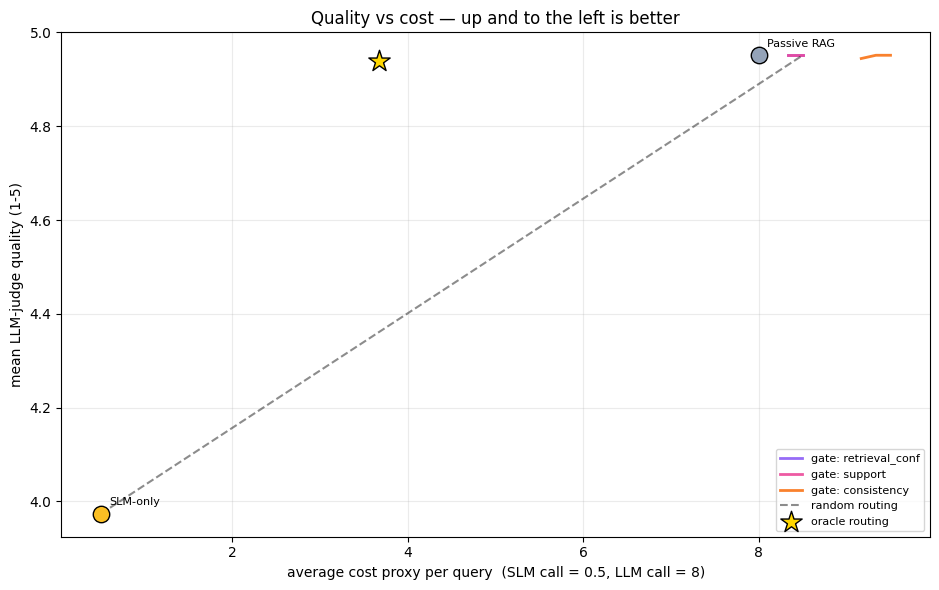

In [27]:
# ============================================================
# GATE ANALYSIS — AUROC, Pareto sweep, dev-split calibration, held-out test
# ============================================================
def make_split(eval_set):
    '''Deterministic dev/test split, stratified by difficulty (alternating within each tier).'''
    split = {}
    for diff in ["L1", "L2", "L3"]:
        ids = sorted(q["id"] for q in eval_set if q["difficulty"] == diff)
        for i, qid in enumerate(ids):
            split[qid] = "dev" if i % 2 == 0 else "test"
    return split

SPLIT = make_split(EVAL_SET)
DEV_IDS  = [i for i, s in SPLIT.items() if s == "dev"]
TEST_IDS = [i for i, s in SPLIT.items() if s == "test"]

def _pair(slm_df, llm_df, ids=None):
    sig_cols = [c for c in slm_df.columns if c.startswith("sig_") or (c.startswith("lat_") and c != "latency_s")]
    s = slm_df[["id", "difficulty", "judge_overall", "cost_proxy", "latency_s"] + sig_cols].rename(
        columns={"judge_overall": "q_slm", "cost_proxy": "cost_slm", "latency_s": "lat_slm"})
    l = llm_df[["id", "judge_overall", "cost_proxy", "latency_s"]].rename(
        columns={"judge_overall": "q_llm", "cost_proxy": "cost_llm", "latency_s": "lat_llm"})
    m = s.merge(l, on="id")
    if ids is not None:
        m = m[m.id.isin(ids)]
    return m.reset_index(drop=True)

def simulate(m, signal, tau):
    '''Offline cascade: escalate (use the LLM answer) when the signal is below tau.'''
    esc = (m[f"sig_{signal}"] < tau).values
    q = np.where(esc, m.q_llm, m.q_slm)
    cost = m.cost_slm + GATE_EXTRA_COST[signal] + esc * m.cost_llm
    lat = m.lat_slm + m[f"lat_{signal}"] + esc * m.lat_llm
    return {"esc_rate": float(esc.mean()), "quality": float(np.mean(q)), "cost": float(np.mean(cost)), "latency": float(np.mean(lat))}

def sweep(m, signal):
    vals = np.sort(m[f"sig_{signal}"].dropna().unique())
    taus = list(vals) + [vals[-1] + 1e-6]          # first tau escalates nobody, last escalates everybody
    return pd.DataFrame([{"tau": t, **simulate(m, signal, t)} for t in taus])

def auroc_low_predicts_bad(sig, bad):
    '''P(a bad answer has a LOWER signal than a good one). 0.5 = chance.'''
    sig, bad = pd.Series(sig).reset_index(drop=True), np.asarray(bad, dtype=bool)
    n1, n0 = int(bad.sum()), int((~bad).sum())
    if n1 == 0 or n0 == 0:
        return np.nan
    r = sig.rank(method="average").values
    p_bad_higher = (r[bad].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
    return 1 - p_bad_higher

def calibrate_gate(slm_df, llm_df, target_frac=TARGET_QUALITY_FRAC):
    m = _pair(slm_df, llm_df, DEV_IDS)
    target = target_frac * m.q_llm.mean()
    best = None
    for sig in SIGNALS:
        if f"sig_{sig}" not in m or m[f"sig_{sig}"].isna().all():
            continue
        sw = sweep(m, sig)
        ok = sw[sw.quality >= target].sort_values(["esc_rate", "tau"]).iloc[0]   # last row always qualifies (escalates all)
        cand = {"signal": sig, "tau": float(ok.tau), "calibrated": True, "dev_esc_rate": float(ok.esc_rate),
                "dev_quality": float(ok.quality), "dev_cost": float(ok.cost), "dev_target": float(target)}
        if best is None or cand["dev_cost"] < best["dev_cost"] - 1e-9:
            best = cand
    return best

# ---- 1) which signal predicts SLM errors? (all questions)
m_all = _pair(df_slm_only, df_passive)
bad = (m_all.q_llm - m_all.q_slm) >= NEED_MARGIN
print(f"SLM answers where the LLM was clearly better (margin >= {NEED_MARGIN}): {int(bad.sum())}/{len(m_all)}")
auc_rows = [{"signal": s, "AUROC (low signal => bad SLM answer)": round(auroc_low_predicts_bad(m_all[f'sig_{s}'], bad), 3),
             "extra_cost": GATE_EXTRA_COST[s]} for s in SIGNALS]
display(pd.DataFrame(auc_rows).set_index("signal"))
if bad.sum() == 0:
    print("⚠ The SLM was never clearly worse than the LLM on this set — a gate has nothing to catch. Check the eval difficulty.")
elif bad.sum() < 5:
    print("⚠ Fewer than 5 'bad' SLM answers: AUROC and the calibrated threshold are very noisy. Treat them as illustrative.")

# ---- 2) calibrate on dev, report on held-out test
cal = calibrate_gate(df_slm_only, df_passive)
GATE.update(cal)
print(f"\nCalibrated on {len(DEV_IDS)} dev questions -> signal='{GATE['signal']}', tau={GATE['tau']:.3f} "
      f"(escalates {GATE['dev_esc_rate']:.0%} of dev queries; dev quality {GATE['dev_quality']:.3f} vs target {GATE['dev_target']:.3f})")
if GATE["dev_esc_rate"] == 0:
    print("⚠ The SLM already meets the quality target on dev, so the gate escalates nothing. SLM-only may simply be enough here.")

mt = _pair(df_slm_only, df_passive, TEST_IDS)
sim_t = simulate(mt, GATE["signal"], GATE["tau"])
p_esc = sim_t["esc_rate"]
oracle_t = np.maximum(mt.q_slm, mt.q_llm)
oracle_esc = (mt.q_llm > mt.q_slm)
rows = [
    {"policy": "SLM-only (never escalate)",      "quality": mt.q_slm.mean(), "cost": mt.cost_slm.mean(), "esc_rate": 0.0},
    {"policy": "Passive RAG (always LLM)",       "quality": mt.q_llm.mean(), "cost": mt.cost_llm.mean(), "esc_rate": 1.0},
    {"policy": f"Cascade gate ({GATE['signal']}), dev-calibrated", "quality": sim_t["quality"], "cost": sim_t["cost"], "esc_rate": p_esc},
    {"policy": "Random routing, same escalation rate", "quality": (1 - p_esc) * mt.q_slm.mean() + p_esc * mt.q_llm.mean(),
     "cost": mt.cost_slm.mean() + p_esc * mt.cost_llm.mean(), "esc_rate": p_esc},
    {"policy": "Oracle routing (upper bound)",   "quality": oracle_t.mean(), "cost": (mt.cost_slm + oracle_esc * mt.cost_llm).mean(), "esc_rate": float(oracle_esc.mean())},
]
test_tbl = pd.DataFrame(rows).set_index("policy")
test_tbl["% of Passive quality"] = (100 * test_tbl.quality / mt.q_llm.mean()).round(1)
test_tbl["% of Passive cost"] = (100 * test_tbl.cost / mt.cost_llm.mean()).round(1)
print(f"\n=== HELD-OUT TEST SPLIT ({len(TEST_IDS)} questions, never used to pick the threshold) — simulated, no extra model calls ===")
display(test_tbl.round(3))

def plot_pareto(m, measured=None, fname="pareto.png"):
    fig, ax = plt.subplots(figsize=(9.5, 6))
    sig_colors = {"retrieval_conf": "#8b5cf6", "support": "#ec4899", "consistency": "#f97316"}
    for s in SIGNALS:
        if f"sig_{s}" in m and not m[f"sig_{s}"].isna().all():
            sw = sweep(m, s)
            ax.plot(sw.cost, sw.quality, "-", color=sig_colors[s], lw=2, alpha=0.9, label=f"gate: {s}")
    ax.plot([m.cost_slm.mean(), m.cost_slm.mean() + m.cost_llm.mean()], [m.q_slm.mean(), m.q_llm.mean()],
            "k--", alpha=0.45, label="random routing")
    o_esc = (m.q_llm > m.q_slm)
    ax.scatter([(m.cost_slm + o_esc * m.cost_llm).mean()], [np.maximum(m.q_slm, m.q_llm).mean()],
               marker="*", s=260, color="gold", edgecolor="k", zorder=6, label="oracle routing")
    if measured is not None:
        for p, g in measured.groupby("pipeline"):
            ax.scatter(g.cost_proxy.mean(), g.judge_overall.mean(), s=140, color=COLORS.get(p, "gray"),
                       edgecolor="k", zorder=5)
            ax.annotate(p, (g.cost_proxy.mean(), g.judge_overall.mean()), textcoords="offset points",
                        xytext=(6, 6), fontsize=8)
    else:
        for lbl, c, q, col in [("SLM-only", m.cost_slm.mean(), m.q_slm.mean(), COLORS["SLM-only"]),
                               ("Passive RAG", m.cost_llm.mean(), m.q_llm.mean(), COLORS["Passive RAG (LLM-only)"])]:
            ax.scatter(c, q, s=140, color=col, edgecolor="k", zorder=5)
            ax.annotate(lbl, (c, q), textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_xlabel("average cost proxy per query  (SLM call = 0.5, LLM call = 8)")
    ax.set_ylabel("mean LLM-judge quality (1-5)")
    ax.set_title("Quality vs cost — up and to the left is better")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{fname}", dpi=120)
    plt.show()

plot_pareto(m_all, fname="pareto_simulated.png")

### 5.3 Run the remaining pipelines (with the calibrated gate)
Hybrid v1, the Cascade (live, using the calibrated gate), and the Agentic pipeline. Cached results are tagged with the gate setting, so changing the threshold re-runs only the pipelines that depend on it.

In [ ]:
# ============================================================
# RUN THE REMAINING PIPELINES
# ============================================================
_gate_tag = f"{GATE['signal']}_{GATE['tau']:.3f}".replace(".", "p").replace("-", "m")

df_hybrid  = run_or_load("Hybrid v1 (stage-split)", hybrid_rag_generate, EVAL_SET)
df_cascade = run_or_load("Hybrid Cascade (gated)", cascade_rag_generate, EVAL_SET, tag=_gate_tag)
df_agentic = run_or_load("Hybrid + Agentic", multi_agent_generate, EVAL_SET, tag=_gate_tag)

all_results_full = pd.concat([df_slm_only, df_passive, df_hybrid, df_cascade, df_agentic], ignore_index=True)
print("✓", len(all_results_full), "rows across", all_results_full.pipeline.nunique(), "pipelines")

▶ Hybrid v1 (stage-split): running 48 questions ...
   Hybrid v1 (stage-split): 10/48
   Hybrid v1 (stage-split): 20/48
   Hybrid v1 (stage-split): 30/48
   Hybrid v1 (stage-split): 40/48
✓ Hybrid v1 (stage-split): done in 740s, cached -> cache_hybrid_v1_stage_split_64a01ec5.json
▶ Hybrid Cascade (gated): running 48 questions ...


### 5.4 Question audit — exclude only questions that are *broken*, by rules fixed in advance
A question is excluded only if one of these **pipeline-agnostic** rules fires — never because one particular pipeline did badly on it:

1. **KB-unsupported** — fewer than half of its key terms appear anywhere in the KB (no pipeline could answer it).
2. **Judge failure** — the judge output could not be parsed for at least one pipeline (a harness bug, not an answer-quality signal).
3. **Fails everywhere** — at least 3 of the 5 pipelines, *including the LLM-only baseline*, score below 3.5 (suggests a bad reference answer or a broken question).
4. **Manual** — listed in `MANUAL_EXCLUDE` with a written reason.

A question that **only one** pipeline fails is exactly the kind of evidence this workshop is about, so it stays. Both the full and the audited sets are printed below.

**Safety cap:** the automatic rules may exclude at most `MAX_AUTO_EXCLUDE_FRAC` (10%) of the set. If they would exclude more, the cell refuses and warns — that pattern means the *judge or a pipeline* is broken, and silently dropping half the benchmark would hide it.

In [ ]:
# ============================================================
# QUESTION AUDIT — rules fixed in advance, applied identically to every pipeline
# ============================================================
piv = all_results_full.pivot(index="id", columns="pipeline", values="judge_overall")
flags = pd.DataFrame(index=piv.index)
flags["kb_unsupported"] = kb_audit.set_index("id").kb_term_support.reindex(piv.index) < 0.5
flags["judge_failure"] = piv.isna().any(axis=1)
flags["fails_everywhere"] = ((piv < 3.5).sum(axis=1) >= 3) & (piv["Passive RAG (LLM-only)"] < 3.5)
flags["manual"] = [i in MANUAL_EXCLUDE for i in piv.index]
auto_flagged = flags.index[flags[["kb_unsupported", "judge_failure", "fails_everywhere"]].any(axis=1)].tolist()
manual_ids = flags.index[flags["manual"]].tolist()

# SAFETY CAP: if the automatic rules want to drop more than MAX_AUTO_EXCLUDE_FRAC of the set, the problem is almost
# certainly the judge or a broken pipeline — not dozens of bad questions. Refuse to auto-exclude and say so loudly.
if len(auto_flagged) > MAX_AUTO_EXCLUDE_FRAC * len(piv):
    print(f"⚠ {len(auto_flagged)} of {len(piv)} questions tripped the automatic rules (cap = {MAX_AUTO_EXCLUDE_FRAC:.0%}).")
    print("  That many is a sign the judge or a pipeline is broken, not that the questions are. NOT auto-excluding anything.")
    print("  Inspect df_*['judge_reason'] and the answers first; fix the cause, then re-run.")
    display(pd.concat([flags.loc[auto_flagged], piv.loc[auto_flagged].round(2)], axis=1))
    auto_flagged = []
excluded_ids = sorted(set(auto_flagged) | set(manual_ids))

if excluded_ids:
    print(f"Excluded {len(excluded_ids)} question(s) by the pre-defined rules:")
    rep = flags.loc[excluded_ids].copy()
    rep["manual_reason"] = [MANUAL_EXCLUDE.get(i, "") for i in excluded_ids]
    display(pd.concat([rep, piv.loc[excluded_ids].round(2)], axis=1))
else:
    print("No question met the exclusion rules, so the audited set equals the full set.")
    print("Low scores you see below are therefore PIPELINE failures on valid questions, not bad data.")

res = all_results_full[~all_results_full.id.isin(excluded_ids)].copy()
print(f"\nAudited set: {res.id.nunique()} questions (full set: {all_results_full.id.nunique()})")
print("judge_overall by pipeline — full vs audited:")
display(pd.DataFrame({"full": all_results_full.groupby("pipeline").judge_overall.mean(),
                      "audited": res.groupby("pipeline").judge_overall.mean()}).reindex(PIPELINE_ORDER).round(3))

### 5.5 Summary with uncertainty — bootstrap CIs, paired comparisons, cost sensitivity

In [ ]:
# ============================================================
# SUMMARY TABLE — with bootstrap confidence intervals
# ============================================================
rng = np.random.default_rng(0)

def boot_ci(x, n=BOOTSTRAP_N):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    means = rng.choice(x, size=(n, len(x)), replace=True).mean(axis=1)
    return float(x.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))

def llm_cost_share(g):
    slm = g.n_slm_calls.sum() * COST_WEIGHTS["SLM"]
    llm = g.n_llm_calls.sum() * COST_WEIGHTS["LLM"]
    return llm / (slm + llm) if (slm + llm) else 0.0

rows = []
for p in PIPELINE_ORDER:
    g = res[res.pipeline == p]
    mean, lo, hi = boot_ci(g.judge_overall)
    rows.append({
        "pipeline": p, "judge_overall": mean, "ci95_low": lo, "ci95_high": hi,
        "judge_correctness": g.judge_correctness.mean(), "judge_completeness": g.judge_completeness.mean(),
        "judge_groundedness": g.judge_groundedness.mean(),
        "term_coverage": g.term_coverage.mean(), "semantic_relevance": g.semantic_relevance.mean(),
        "latency_p50": np.percentile(g.latency_s, 50), "latency_p95": np.percentile(g.latency_s, 95),
        "llm_call_fraction": g.n_llm_calls.sum() / max(g.n_llm_calls.sum() + g.n_slm_calls.sum(), 1),
        "llm_cost_share": llm_cost_share(g), "avg_cost_proxy": g.cost_proxy.mean(),
        "escalation_rate": g.escalated.astype(float).mean() if g.escalated.notna().any() else np.nan,
    })
overall = pd.DataFrame(rows).set_index("pipeline")
passive_q, passive_c = overall.loc["Passive RAG (LLM-only)", "judge_overall"], overall.loc["Passive RAG (LLM-only)", "avg_cost_proxy"]
overall["pct_of_passive_quality"] = 100 * overall.judge_overall / passive_q
overall["pct_of_passive_cost"] = 100 * overall.avg_cost_proxy / passive_c
overall = overall.round(3)
print("=== OVERALL (judge_overall is the headline quality metric, 1-5; ci95 = bootstrap over questions) ===")
display(overall)

by_diff = res.groupby(["pipeline", "difficulty"]).agg(
    judge_overall=("judge_overall", "mean"), term_coverage=("term_coverage", "mean"),
    semantic_relevance=("semantic_relevance", "mean"), latency_s=("latency_s", "mean")).round(3)
print("\n=== BY DIFFICULTY ===")
display(by_diff.loc[PIPELINE_ORDER])

# ---- paired comparisons: same questions, so compare per-question differences, not just means
def paired(a, b, col="judge_overall"):
    p = res.pivot(index="id", columns="pipeline", values=col)
    d = (p[a] - p[b]).dropna().values
    means = rng.choice(d, size=(BOOTSTRAP_N, len(d)), replace=True).mean(axis=1)
    return {"mean_diff": d.mean(), "ci95_low": np.percentile(means, 2.5), "ci95_high": np.percentile(means, 97.5),
            "wins": int((d > 1e-9).sum()), "ties": int((np.abs(d) <= 1e-9).sum()), "losses": int((d < -1e-9).sum()),
            "significant": bool(np.percentile(means, 2.5) > 0 or np.percentile(means, 97.5) < 0)}

pc = []
for ref in ["Passive RAG (LLM-only)", "SLM-only"]:
    for p in PIPELINE_ORDER:
        if p != ref:
            pc.append({"pipeline": p, "vs": ref, **paired(p, ref)})
print("\n=== PAIRED COMPARISONS (judge_overall difference; 'significant' = 95% CI excludes 0) ===")
display(pd.DataFrame(pc).set_index(["vs", "pipeline"]).round(3))

# ---- cost sensitivity: the 8:0.5 = 16x LLM:SLM weight is an ASSUMPTION — test it
def cost_under(g, ratio=None, token_weighted=False):
    slm_w = 0.5
    llm_w = slm_w * (ratio if ratio is not None else 16)
    if token_weighted:
        return (g.slm_tokens * slm_w + g.llm_tokens * llm_w).mean()
    return (g.n_slm_calls * slm_w + g.n_llm_calls * llm_w).mean()

sens = {}
for p in PIPELINE_ORDER:
    g = res[res.pipeline == p]
    sens[p] = {f"per-call, LLM={r}x SLM": cost_under(g, r) for r in [4, 16, 50, 100]}
    sens[p]["token-weighted, 16x"] = cost_under(g, 16, token_weighted=True)
sens = pd.DataFrame(sens).T.loc[PIPELINE_ORDER]
sens_pct = (100 * sens / sens.loc["Passive RAG (LLM-only)"]).round(1)
print("\n=== COST SENSITIVITY — each pipeline's cost as % of Passive RAG under different assumptions ===")
print("(token counts are word-split approximations; the point is whether the ranking survives the assumption)")
display(sens_pct)

### 5.6 Charts

In [ ]:
# ============================================================
# CHARTS
# ============================================================
pipelines = PIPELINE_ORDER
bar_colors = [COLORS[p] for p in pipelines]
short = [p.replace(" (LLM-only)", "").replace(" (stage-split)", "").replace(" (gated)", "") for p in pipelines]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
yerr = np.array([overall.judge_overall - overall.ci95_low, overall.ci95_high - overall.judge_overall])
axes[0, 0].bar(short, overall["judge_overall"], color=bar_colors, yerr=yerr, capsize=4)
axes[0, 0].set_title("LLM-Judge Quality (1-5) with 95% bootstrap CI")
axes[0, 0].set_ylim(max(0, overall.ci95_low.min() - 0.5), 5.05)
axes[0, 0].tick_params(axis="x", rotation=15)

axes[0, 1].bar(short, overall["semantic_relevance"], color=bar_colors)
axes[0, 1].set_title("Semantic Relevance (independent supplementary signal, 0-1)")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=15)

x = np.arange(len(pipelines)); width = 0.35
axes[1, 0].bar(x - width / 2, overall["latency_p50"], width, label="P50", color="#cbd5e1")
axes[1, 0].bar(x + width / 2, overall["latency_p95"], width, label="P95", color="#64748b")
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(short, rotation=15)
axes[1, 0].set_title("Latency (seconds)"); axes[1, 0].legend()

axes[1, 1].bar(short, overall["llm_cost_share"] * 100, color=bar_colors)
axes[1, 1].set_title("% of a pipeline's COST that is LLM calls (call count hides this)")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eval_summary.png", dpi=120)
plt.show()

# ---- quality by difficulty
diff_order = ["L1", "L2", "L3"]
fig, ax = plt.subplots(figsize=(9, 5))
for p in pipelines:
    vals = [res[(res.pipeline == p) & (res.difficulty == d)]["judge_overall"].mean() for d in diff_order]
    ax.plot(diff_order, vals, marker="o", label=p, color=COLORS[p], linewidth=2)
ax.set_ylabel("Mean LLM-Judge Quality (1-5)")
ax.set_title("Quality by Difficulty Tier — where does each capability actually help?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/quality_by_difficulty.png", dpi=120)
plt.show()

# ---- Pareto with the five measured pipelines overlaid on the simulated gate curves
plot_pareto(_pair(df_slm_only, df_passive), measured=res, fname="pareto_measured.png")

# ---- call mix
call_mix = res.groupby("pipeline")[["n_slm_calls", "n_llm_calls"]].sum().loc[PIPELINE_ORDER]
call_mix_pct = call_mix.div(call_mix.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(8, 5))
call_mix_pct.plot(kind="barh", stacked=True, ax=ax, color=["#60a5fa", "#f87171"])
ax.set_xlabel("% of model calls"); ax.set_title("SLM vs. LLM Call Mix (own generative calls only)")
ax.legend(["SLM calls", "LLM calls"], loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/call_mix.png", dpi=120)
plt.show()
print(call_mix)

### 5.7 Did the escalations land on the right questions?
Escalating is only worth the LLM call if the LLM actually does better. Against the offline oracle (`LLM answer ≥ SLM answer + NEED_MARGIN`) we compute, for each escalation trigger:
**precision** (of the queries it escalated, how many truly needed it) and **recall** (of the queries that needed it, how many it caught). In v1 the orchestrator's guess had neither.

In [ ]:
# ============================================================
# ESCALATION QUALITY — precision / recall against the offline oracle
# ============================================================
m_orc = _pair(df_slm_only, df_passive)[["id", "q_slm", "q_llm"]]
m_orc["needed"] = (m_orc.q_llm - m_orc.q_slm) >= NEED_MARGIN
m_orc = m_orc[m_orc.id.isin(res.id.unique())]

def esc_quality(df, col, label):
    d = df[["id", col]].dropna().merge(m_orc, on="id")
    esc = d[col].astype(bool)
    tp = int((esc & d.needed).sum())
    return {"trigger": label, "escalation_rate": float(esc.mean()),
            "precision": tp / max(int(esc.sum()), 1) if esc.any() else np.nan,
            "recall": tp / max(int(d.needed.sum()), 1) if d.needed.any() else np.nan,
            "needed_total": int(d.needed.sum())}

rows = [esc_quality(df_cascade, "escalated", "Cascade — confidence gate"),
        esc_quality(df_agentic, "orch_escalate", "Agentic — SLM orchestrator's guess"),
        esc_quality(df_agentic, "gate_escalate", "Agentic — gate / self-grade after the draft"),
        esc_quality(df_agentic, "escalated", "Agentic — both combined")]
print("(precision/recall are NaN when a trigger never fired or no question 'needed' the LLM)")
display(pd.DataFrame(rows).set_index("trigger").round(3))

for name, df in [("Cascade", df_cascade), ("Agentic", df_agentic)]:
    d = df[df.id.isin(res.id.unique())]
    if d.escalated.notna().any():
        g = d.groupby(d.escalated.astype(bool)).judge_overall.agg(["mean", "count"]).round(3)
        g.index = ["stayed on SLM" if not i else "escalated to LLM" for i in g.index]
        print(f"\n{name}: judge quality by outcome"); display(g)

### 5.8 Reading the results with the group
Let the tables decide — don't walk in with the conclusion. In order:

1. **Headline vs uncertainty.** Is each pipeline's `judge_overall` CI separated from Passive RAG's, or do the intervals overlap? Check the paired table: how many wins / ties / losses, and is the difference "significant"? (With 48 questions, a 0.05 gap is usually noise.)
2. **Is the cascade on the Pareto frontier?** In the quality-vs-cost chart, does the live Cascade point sit above the random-routing line and near the gate curve? How close is it to the oracle star? That gap is the headroom a better gate could still capture.
3. **Which signal predicts errors?** Compare the AUROCs. A signal near 0.5 is a coin flip; discuss why `support` or `consistency` might beat `retrieval_conf` (or not) with a 0.5B drafter.
4. **Dev vs test.** Did the dev-calibrated threshold hold on the held-out half? A big drop means the threshold was overfit to ~24 questions.
5. **Escalation precision/recall.** Did the orchestrator's guess beat the gate? What does it say about asking a tiny model whether *it* is good enough?
6. **Cost under other assumptions.** Does the ranking in the sensitivity table survive LLM = 4x, 50x, 100x SLM, and token weighting? A conclusion that flips with the assumption is not a conclusion.
7. **Judge caveats.** The judge shares a model with the LLM stages. Compare its ranking with term coverage and semantic relevance; where they disagree, open the human-review sample (Section 5.9).
8. **Stage-split v1.** It still pays for two LLM calls on every query. What does that say about "hybrid" as a label versus *where the LLM is actually spent*?

In [ ]:
# ============================================================
# 5.9 HUMAN-REVIEW SAMPLE + SAVE RESULTS
# A second pair of eyes beats a second judge prompt when the judge shares a model with a pipeline.
# ============================================================
rev = res.copy()
lowest = rev.nsmallest(8, "judge_overall")
disagree = rev[(rev.judge_overall >= 4.5) & (rev.term_coverage < 0.5) & (rev.semantic_relevance < 0.5)].head(6)
rnd = rev.drop(index=lowest.index.union(disagree.index)).sample(n=min(6, max(len(rev) - len(lowest) - len(disagree), 0)), random_state=0)
review = pd.concat([lowest.assign(why="lowest judge score"), disagree.assign(why="judge high but term/semantic low"),
                    rnd.assign(why="random")])
q_text = {q["id"]: (q["question"], q["reference_answer"]) for q in EVAL_SET}
review["question"] = review.id.map(lambda i: q_text[i][0])
review["reference_answer"] = review.id.map(lambda i: q_text[i][1])
review = review[["why", "pipeline", "id", "difficulty", "question", "reference_answer", "answer",
                 "judge_overall", "judge_reason", "term_coverage", "semantic_relevance"]]
review["human_score_1_to_5"] = ""
review.to_csv(f"{RESULTS_DIR}/human_review_sample.csv", index=False)

all_results_full.to_json(f"{RESULTS_DIR}/eval_results.json", orient="records", indent=2)
overall.to_csv(f"{RESULTS_DIR}/overall_summary.csv")
by_diff.to_csv(f"{RESULTS_DIR}/by_difficulty_summary.csv")
pd.DataFrame(pc).to_csv(f"{RESULTS_DIR}/paired_comparisons.csv", index=False)
sens_pct.to_csv(f"{RESULTS_DIR}/cost_sensitivity.csv")
test_tbl.to_csv(f"{RESULTS_DIR}/gate_test_split.csv")

summary = {
    "stage_model_map": {
        "query_rewrite": "SLM", "intent_classification": "SLM (agentic router only)", "retrieval": "embedding-model",
        "reranking": "SLM-tier cross-encoder", "sufficiency_check": "LLM (hybrid v1 only)", "extraction": "SLM (optional, off by default)",
        "synthesis": "LLM", "confidence_gate": "non-generative signal (+2 SLM samples if 'consistency')",
        "self_reflection": "SLM", "multi_agent_orchestration": "SLM",
    },
    "gate": {k: v for k, v in GATE.items()},
    "eval_set": {"n_questions": len(EVAL_SET), "audited_questions": int(res.id.nunique()), "excluded": excluded_ids,
                 "manual_exclusions": MANUAL_EXCLUDE},
    "eval_method": "Anchored LLM-judge rubric (correctness/completeness/groundedness, 1-5) as primary quality metric; term coverage and "
                   "semantic similarity as supplementary signals; bootstrap CIs and paired comparisons; gate calibrated on a dev split "
                   "and reported on a held-out test split; judge calls excluded from each pipeline's own SLM/LLM call-mix. "
                   "Known limitation: the judge shares a model with the LLM stages (possible self-preference).",
    "overall": overall.to_dict(),
}
with open(f"{RESULTS_DIR}/pipeline_design_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"✓ Saved to {RESULTS_DIR}/")
print("  - eval_results.json (raw per-question scores incl. answers, judge_reason, gate signals)")
print("  - overall_summary.csv, by_difficulty_summary.csv, paired_comparisons.csv, cost_sensitivity.csv, gate_test_split.csv")
print("  - pipeline_design_summary.json, human_review_sample.csv (fill in human_score_1_to_5 for ~20 rows)")

---
## Beyond quality — the arguments a quality-vs-cost chart can't make
Even if a cascade only *ties* LLM-only on this benchmark, a hybrid design can still be the right call. Discuss, then plug your own numbers into the projection below.

* **Data locality / privacy** — if the SLM runs on-prem, most queries never leave your network; only escalated, de-identified context goes to a larger model.
* **Throughput and tail latency** — a 0.5B model on one GPU serves many more concurrent requests than an 8B or 70B model, so capacity (not just per-query cost) improves.
* **Graceful degradation** — if the large model is rate-limited or down, a cascade can still answer from the SLM and flag lower confidence.
* **Where the cost really goes** — a stage-split design with two always-on LLM calls is *not* cheaper than LLM-only (Section 3 caveat). Cost savings come from *how rarely* the LLM is called.
* **Honest limits** — a 0.5B drafter plus a confidence gate can miss confident-but-wrong answers; the human-review sample and the oracle gap tell you how much.

In [ ]:
# ============================================================
# SCALE PROJECTION — ILLUSTRATIVE. The prices below are PLACEHOLDERS: replace them with your real
# self-hosted GPU cost per token (SLM) and your LLM provider's price. Tokens are word-split approximations.
# ============================================================
PRICE_PER_1K_TOKENS = {"SLM": 0.0002, "LLM": 0.0020}   # <-- placeholder USD per 1K tokens, edit me
QUERIES_PER_MONTH   = 1_000_000

tok = res.groupby("pipeline")[["slm_tokens", "llm_tokens"]].mean().loc[PIPELINE_ORDER]
per_query = tok.slm_tokens / 1000 * PRICE_PER_1K_TOKENS["SLM"] + tok.llm_tokens / 1000 * PRICE_PER_1K_TOKENS["LLM"]
proj = pd.DataFrame({
    "avg_tokens_per_query": (tok.slm_tokens + tok.llm_tokens).round(0),
    "usd_per_query": per_query.round(6),
    f"usd_per_month @ {QUERIES_PER_MONTH:,} q": (per_query * QUERIES_PER_MONTH).round(0),
    "judge_overall": overall.judge_overall,
})
display(proj)

---
## Wrap-up

You now have, end to end:
- Two **baselines** that bound the problem: **SLM-only** (cheap, naive) and **Passive RAG / LLM-only** (every call on the frontier model).
- A **stage-split hybrid (v1)** — and an honest look at why splitting stages alone doesn't save money when two LLM calls remain on every query.
- A **cascade** where the SLM answers first and a cheap **confidence gate** decides when to escalate, with the gate signal and threshold **chosen on a dev split and reported on a held-out test split**, compared against random and oracle routing on a Pareto curve.
- An **agentic layer** where the SLM orchestrates routing and self-reflects, with the gate as a safety net — and a direct measurement of whether its escalations hit the right questions.
- A harder **48-question eval** with distractor documents and multi-hop items, an **anchored LLM judge**, **bootstrap confidence intervals**, **paired win/tie/loss comparisons**, a **pre-defined question audit**, **cost sensitivity**, and a **human-review export** — so the conclusions come with their uncertainty attached.

**Try during the workshop:**
- Set `TARGET_QUALITY_FRAC` to 0.95 or 1.0 and watch how the escalation rate (and cost) moves along the Pareto curve.
- Set `ORCHESTRATOR_CAN_ESCALATE = False`, set `FORCE_RERUN = True`, and compare the agentic pipeline when only the gate escalates.
- Swap in a different drafter or judge model (change `SLM_MODEL_ID`, or load a second model for judging) and see which conclusions survive.
- Add near-duplicate or out-of-KB questions to see how the gate behaves when retrieval is genuinely insufficient (keep the total at 50 or fewer).